# **Notebook para la elección de decisiones de Padding, Window Size o Scaler**

En este notebook se realizará una experimentación sobre tres decisiones sensibles del modelado:

* **Tamaño de la Ventana de Contexto:** Elección de la cantidad de contexto (en horas) necesaria para construir un modelo robusto y consistente.

* **Tipo de Escalado:** Se discutirá cuál de los Scaler presenta mejor rendimiento sobre este conjunto de datos.

* **Tipo de Padding:** En caso de que haya registros faltantes en inferencia, debemos "rellenarlos" de alguna forma. De este modo, compararemos diferentes estrategias y seleccionaremos aquella que obtenga resultados más satisfactorios.

Cada una de estas decisiones se tomará de acuerdo a los resultados de cada uno de los modelos en el conjunto de validación, de modo que no usaremos el conjunto de test para esta comparativa.

### **LIBRERÍAS**

In [1]:
# ==============================================================================
# 0. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN INICIAL
# ==============================================================================

# --- Manipulación de Datos y Visualización ---
import pandas as pd                 # Para el manejo de datos tabulares, DataFrames y análisis exploratorio.
import numpy as np                  # Operaciones matriciales, vectores y arrays multidimensionales de alta eficiencia.
import matplotlib.pyplot as plt     # Gráficos simples.
import seaborn as sns               # Gráficos estadísticos complejos.

# --- Utilidades del Sistema y Flujo de Memoria ---
import os                           # Interacción con el SO y variables de entorno del equipo.
import joblib                       # Guardar (dump) objetos/preprocesadores grandes de Scikit-Learn.
import time                         # Evaluar latencias y cronometrar los scripts.
from tqdm import tqdm               # Barra de progreso durante iteraciones largas.
import gc                           # Garbage Collector: Borrado de la RAM 
import random                       # Aleatoriedad
from itertools import cycle         # Iterar infinitamente de un bloque circular de objetos y listas.
from pathlib import Path            # Mapear rutas del disco al SO.
import pickle                       # Estandarización Python pura 

# --- Deep Learning: TensorFlow y Keras ---
import tensorflow as tf     # Backend completo de IA para operaciones tensoriales.
from tensorflow.keras.models import Model, load_model   # API Computacional Funcional de Keras y Cargar Modelo.
from tensorflow.keras.optimizers import Adam            # Optimizador para ajustar la pérdida con gradiente estocástico.
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint    # Métodos de vigilancia para parar de aprender si el loss del Valid se estanca.
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization               # Arquitectura para conectividad completa (Dense) y regularizadores del sobreajuste (Dropout/BatchNorm).
from tensorflow.keras.layers import LSTM, GRU, Bidirectional                                # Redes recurrentes: para el entendimiento temporal clásico e incubativo (memoria).
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, MaxPooling1D            # Redes convolucionales: capaces de detectar rápidamente caídas/subidas y picos de alerta sin basarse en contexto lejano.

# --- Machine Learning Numérico y Métricas Clásicas (Scikit-Learn) ---
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler    # Escalado físico y codificador binario para preparar features.
from sklearn.model_selection import train_test_split    # Realiza "Holdout"; es tu base real de división controlada en capas representativas (estratificadas).
from sklearn.utils import class_weight                  # Computa los desbalances permitiéndote penalizar en coste a la red por fallar las muestras extrañas.
from sklearn.preprocessing import label_binarize        # Binarización útil para análisis complejos ROC.
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score # Toolkit de evaluación técnica multiclase (Clasificación).
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # Toolkit para evaluación de regresión (El 'Grade de infeción' analóguco calculado).

# --- Configuración Global ---
pd.set_option('display.max_columns', None)  # Muestra todas las columnas de df
np.random.seed(42)                          # Replicabilidad

---

# **SELECCIÓN DE WINDOW_SIZE**

## **Tamaño de la Ventana: 7 días**

In [2]:
# =========================================================
# CONFIGURACIONES DEL MODELO:
# =========================================================
DIAS_CONTEXTO = 7
WINDOW_SIZE = DIAS_CONTEXTO * 24   # Horas de contexto
BATCH_SIZE = 512    # Memoria
EPOCHS = 50         # Epocas de entrenamiento
EARLY_STOPPING = 2  # Patience

# ==========================================================
# CARGA DE DATOS:
# ==========================================================
df = pd.read_parquet("../../data/processed/data_vin_processed.parquet")

# ==========================================================
# PREPROCESAMIENTO:
# ==========================================================
# Orden alfabético
df = df.reindex(sorted(df.columns), axis=1)

# Asegurar tipos string para evitar errores en el modelo:
cols_str = ['Etiqueta_Clase', 'Clase_Entrenamiento']
for col in cols_str:
    if col in df.columns:
        df[col] = df[col].astype(str)

# 1. CODIFICACIÓN DE TARGETS
le = LabelEncoder()
# TARGET: El estado real en ese instante temporal
df['Etiqueta_Num'] = le.fit_transform(df['Clase_Entrenamiento']) 
print(f"✅ Clases codificadas: {dict(zip(le.classes_, range(len(le.classes_))))}")

# 2. SELECCIÓN DE VARIABLES
# Quitamos Fecha (ya no sirve a la red), ID_Serie (no es predictiva) y Etiquetas crudas
cols_features = [
    'Temp_Amb_C', 
    'Hum_Rel_Pct', 'Lluvia_mm', 'Viento_kmh', 
    'Horas_Humedad_Foliar', 'GDD_Acumulado', 
    'Hum_Suelo_Pct', 'pH_Suelo',
    'Hora_Sin', 'Hora_Cos',
    'CO2_ppm', 'VOC_ppb'
]

target_class = 'Etiqueta_Num'
target_reg = 'Grado_Infeccion'

# 3. SPLIT ESTRATÉGICO ESTRATIFICADO (POR ID_SERIE, NUNCA ALEATORIO POR FILA)
# Obtenemos un diccionario 1 a 1 de cada ID_Serie con su patología general
df_unicos = df.drop_duplicates(subset=['ID_Serie'])[['ID_Serie', 'Etiqueta_Clase']]

ids = df_unicos['ID_Serie']
etiquetas = df_unicos['Etiqueta_Clase']

# Primer Split: 70% Train, 30% Temp (Estratificado por la etiqueta)
train_ids, temp_ids, _, temp_etiquetas = train_test_split(
    ids, etiquetas, 
    test_size=0.30, 
    random_state=42, 
    stratify=etiquetas
)

# Segundo Split: Dividimos el 30% restante en 15% Val y 15% Test
val_ids, test_ids = train_test_split(
    temp_ids, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_etiquetas
)

# Reconstruimos los DataFrames completos usando los IDs seleccionados
train_df = df[df['ID_Serie'].isin(train_ids)].copy()
val_df = df[df['ID_Serie'].isin(val_ids)].copy()
test_df = df[df['ID_Serie'].isin(test_ids)].copy()

print(f"📊 Series separadas -> Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

# 4. ESCALADO
scaler = StandardScaler()
# Ajustamos solo en train para evitar fuga de datos
scaler.fit(train_df[cols_features])

# Transformamos todos
train_df[cols_features] = scaler.transform(train_df[cols_features])
val_df[cols_features] = scaler.transform(val_df[cols_features])
test_df[cols_features] = scaler.transform(test_df[cols_features])
print("✅ Datos escalados correctamente.")

# 5. GENERACIÓN DE VENTANAS TEMPORALES (MEMORIA OPTIMIZADA)
def crear_secuencias(df_part, window_size, features, t_class, t_reg):
    X, y_c, y_r = [], [], []
    grupos = df_part.groupby('ID_Serie')
    
    for _, grupo in tqdm(grupos, desc="Generando tensores", leave=False):
        data_features = grupo[features].values
        data_class = grupo[t_class].values
        data_reg = grupo[t_reg].values
        
        # Deslizamiento de ventana
        for i in range(len(data_features) - window_size):
            X.append(data_features[i : i + window_size])
            # El target es el estado al FINAL de la ventana
            y_c.append(data_class[i + window_size])
            y_r.append(data_reg[i + window_size])
            
    return np.array(X, dtype=np.float32), np.array(y_c, dtype=np.int8), np.array(y_r, dtype=np.float32)

print("\n🚀 Empaquetando tensores 3D (Esto tomará un minuto)...")
X_train, y_train_class, y_train_reg = crear_secuencias(train_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_val, y_val_class, y_val_reg = crear_secuencias(val_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_test, y_test_class, y_test_reg = crear_secuencias(test_df, WINDOW_SIZE, cols_features, target_class, target_reg)

# Limpiar RAM
del train_df, val_df, test_df
gc.collect()

# ==============================================================================
# DEEP ENSEMBLE LEARNING: DEFINICIÓN DE LAS 3 REDES
# ==============================================================================
NUM_FEATURES = len(cols_features)
NUM_CLASSES = len(le.classes_)
tf.keras.utils.set_random_seed(42)

def compilar_modelo(modelo, lr):
    modelo.compile(
        optimizer=Adam(learning_rate=lr),
        loss={"out_class": "sparse_categorical_crossentropy", "out_reg": "mse"},
        loss_weights={"out_class": 1.0, "out_reg": 1.0},
        metrics={"out_class": ["accuracy"], "out_reg": ["mae"]}
    )
    return modelo

# --- MODELO 1: LSTM PURA ---
def build_lstm_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M1")
    x = LSTM(32, return_sequences=True)(inp)  
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)                       
    x = LSTM(16)(x)                           
    x = BatchNormalization()(x)
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M1_LSTM"), lr=0.001)

# --- MODELO 2: CNN-1D ---
def build_cnn_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M2")
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inp)
    x = BatchNormalization()(x)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)                                                           
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M2_CNN"), lr=0.001)

# --- MODELO 3: GRU BIDIRECCIONAL ---
def build_bigru_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M3")
    x = Bidirectional(GRU(16, return_sequences=False))(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(16, activation='relu')(x)
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M3_BiGRU"), lr=0.001)

# Instanciamos los 3 modelos
m1_lstm = build_lstm_model()
m2_cnn = build_cnn_model()
m3_bigru = build_bigru_model()

✅ Clases codificadas: {'ALTICA': 0, 'BLACK_ROT': 1, 'BOTRYTIS': 2, 'EMPOASCA': 3, 'ERINOSIS': 4, 'ESCA': 5, 'HEALTHY': 6, 'LOBESIA': 7, 'MILDIU': 8, 'OIDIO': 9, 'RED_MITE': 10}
📊 Series separadas -> Train: 692 | Val: 148 | Test: 149
✅ Datos escalados correctamente.

🚀 Empaquetando tensores 3D (Esto tomará un minuto)...


In [3]:
# ==============================================================================
# ENTRENAMIENTO DEL ENSEMBLE Y GUARDADO DE ARTEFACTOS
# ==============================================================================

RUTA_MODELS_DIR = Path("pruebas/window1sem/")
NOMBRE_MODELO_LSTM = "M1_LSTM.keras"
NOMBRE_MODELO_CNN = "M2_CNN.keras"
NOMBRE_MODELO_BI_GRU = "M3_BiGRU.keras"

# 1. Guardar los preprocesadores inmediatamente de forma segura
joblib.dump(scaler, "pruebas/window1sem/scaler.pkl")
joblib.dump(le, "pruebas/window1sem/label_encoder.pkl")
print("Preprocesadores guardados en: pruebas/window1sem/")

modelos = [m1_lstm, m2_cnn, m3_bigru]
historiales = []

print("\nIniciando entrenamiento secuencial de redes: ", len(modelos))

start_time_total = time.time()      # INICIO DE CRONÓMETRO TOTAL

for i, modelo in enumerate(modelos):
    print("\n" + "="*50)
    print("Entrenando Modelo: ", modelo.name)
    print("="*50)
    
    start_time_model = time.time()  # INICIO DE CRONÓMETRO MODELO

    # Pre-definimos la ruta donde se guardara ESTE modelo en concreto
    ruta_modelo = RUTA_MODELS_DIR / f"{modelo.name}.keras"
    
    # Instanciamos los Callbacks desde cero para que no crucen historial entre redes
    early_stop_individual = EarlyStopping(
        monitor='val_loss', 
        patience=EARLY_STOPPING, 
        restore_best_weights=True,
        verbose=1
    )
    
    checkpoint_individual = ModelCheckpoint(
        filepath=ruta_modelo,
        monitor='val_loss',        # Vigilamos la perdida de validacion global
        save_best_only=True,       # Solo sobreescribe si la red mejora en esta epoca
        mode='min',                # Queremos minimizar el val_loss
        verbose=1
    )
    
    # Inicia el entrenamiento (Fit)
    hist = modelo.fit(
        X_train, 
        {"out_class": y_train_class, "out_reg": y_train_reg},
        validation_data=(X_val, {"out_class": y_val_class, "out_reg": y_val_reg}),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop_individual, checkpoint_individual],
        verbose=1
    )
    
    # La red (.keras) ya ha sido guardada en su mejor punto por el Checkpoint.
    # Ahora solo necesitamos guardar el historial de la funcion de perdida.
    ruta_historial = RUTA_MODELS_DIR / f"history_{modelo.name}.pkl"
    with open(ruta_historial, 'wb') as f:
        pickle.dump(hist.history, f)
        
    historiales.append(hist.history)
    print("Historial guardado con exito: ", modelo.name)

    end_time_model = time.time()    # FIN DE CRONÓMETRO MODELO
    elapsed_model_mins = (end_time_model - start_time_model) / 60.0
    print(f"⏱️ Tiempo de entrenamiento para {modelo.name}: {elapsed_model_mins:.2f} minutos.")

end_time_total = time.time()        # FIN DE CRONÓMETRO TOTAL
elapsed_total_mins = (end_time_total - start_time_total) / 60.0
print(f"\n⏱️ TIEMPO TOTAL DE ENTRENAMIENTO DEL ENSEMBLE: {elapsed_total_mins:.2f} minutos.")

print("\nENTRENAMIENTO Y EXPORTACION COMPLETADOS. Todos los archivos estan seguros en: ", RUTA_MODELS_DIR.resolve())

Preprocesadores guardados en: pruebas/window1sem/

Iniciando entrenamiento secuencial de redes:  3

Entrenando Modelo:  M1_LSTM
Epoch 1/50
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 1.4876 - out_class_accuracy: 0.4899 - out_class_loss: 1.4422 - out_reg_loss: 0.0455 - out_reg_mae: 0.1548
Epoch 1: val_loss improved from None to 1.04341, saving model to pruebas\window1sem\M1_LSTM.keras
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 268s 133ms/step - loss: 1.1114 - out_class_accuracy: 0.6086 - out_class_loss: 1.0843 - out_reg_loss: 0.0271 - out_reg_mae: 0.1151 - val_loss: 1.0434 - val_out_class_accuracy: 0.6596 - val_out_class_loss: 1.0258 - val_out_reg_loss: 0.0176 - val_out_reg_mae: 0.0886
Epoch 2/50
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.6502 - out_class_accuracy: 0.7605 - out_class_loss: 0.6355 - out_reg_loss: 0.0148 - out_reg_mae: 0.0820
Epoch 2: val_loss improved from 1.04341 to 0.93008, saving model to pruebas\window1sem\M1_LSTM.keras
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 440s 19

✅ Preprocesadores (Scaler y LabelEncoder) cargados correctamente.
✅ Modelos cargados correctamente.
📊 Historial de M1_LSTM cargado con éxito.
📊 Historial de M2_CNN cargado con éxito.
📊 Historial de M3_BiGRU cargado con éxito.

🚀 ¡Todos los artefactos y modelos han sido cargados y están listos para usarse!

🧪 Evaluando Ensemble sobre los datos de Validación...
📊 Generando curvas de aprendizaje para auditar el sobreajuste (Overfitting)...


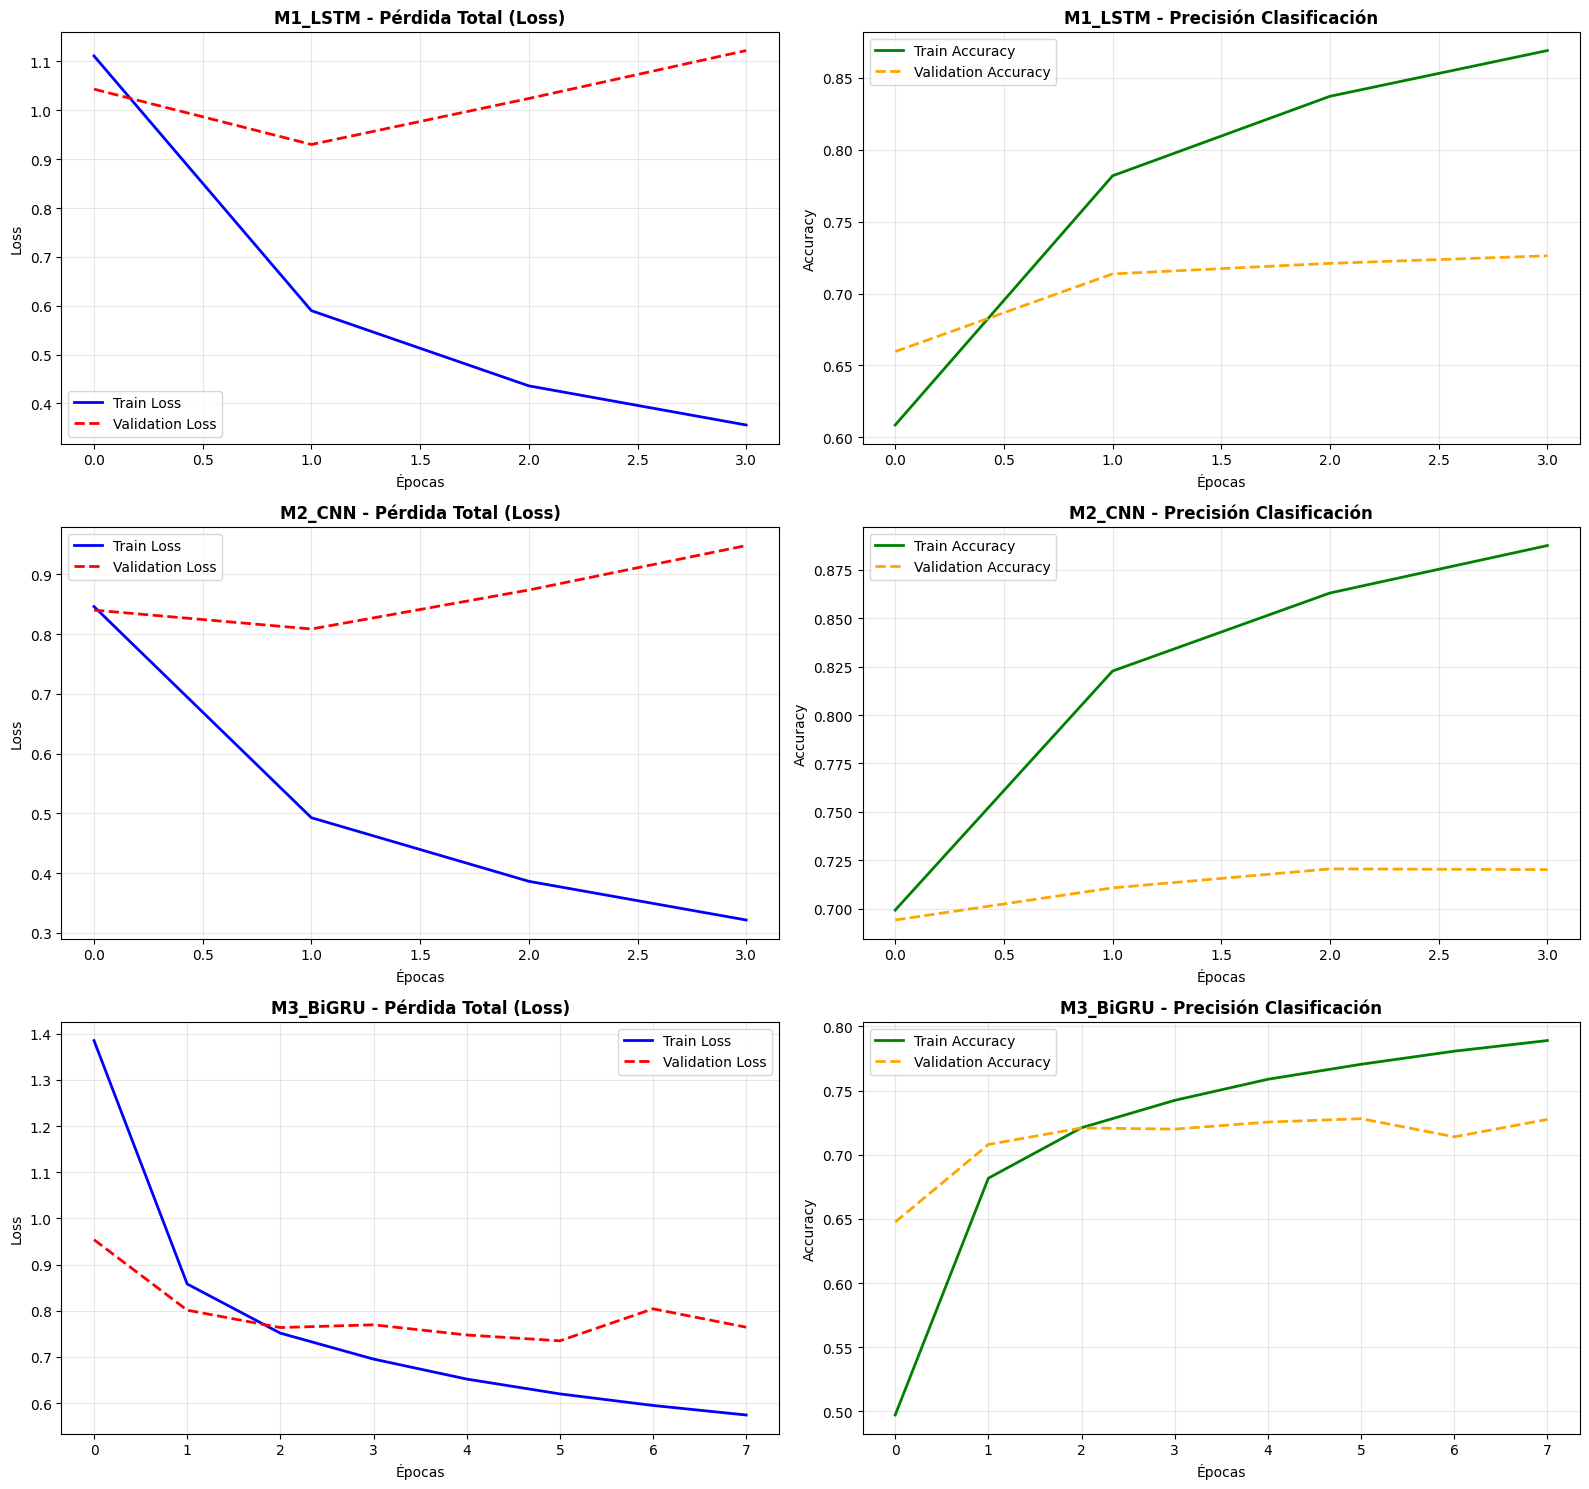


🎯 MÉTRICAS DE VALIDACIÓN EN CLASIFICACIÓN (ENSEMBLE)
              precision    recall  f1-score   support

      ALTICA     0.9887    0.8178    0.8952      2991
   BLACK_ROT     0.7678    0.6535    0.7060     32278
    BOTRYTIS     0.6022    0.5234    0.5600     32079
    EMPOASCA     0.9617    0.9880    0.9747     23275
    ERINOSIS     0.5150    0.5968    0.5529     11706
        ESCA     0.9035    0.9367    0.9198     23508
     HEALTHY     0.8407    0.9099    0.8739     36695
     LOBESIA     0.6948    0.7680    0.7295     22104
      MILDIU     0.3687    0.4449    0.4032     14688
       OIDIO     0.9514    0.9226    0.9368      5619
    RED_MITE     0.8854    0.4754    0.6186      4453

    accuracy                         0.7475    209396
   macro avg     0.7709    0.7306    0.7428    209396
weighted avg     0.7527    0.7475    0.7467    209396



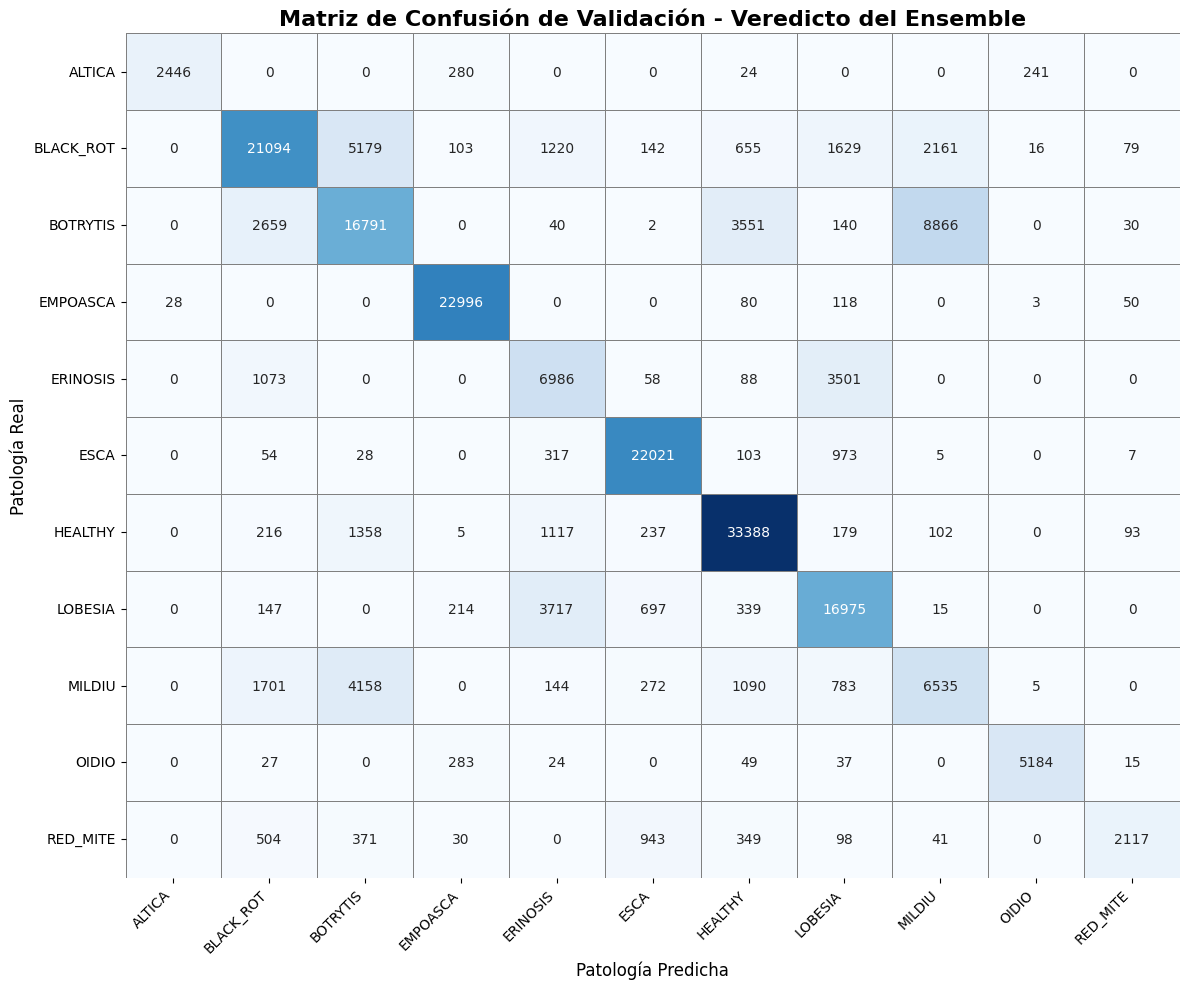


📈 MÉTRICAS DE REGRESIÓN (ENSEMBLE)
MAE  (Mean Absolute Error):      0.0637  (Error medio absoluto en la predicción del daño 0-1)
MSE  (Mean Squared Error):       0.0091  (Penaliza errores grandes)
RMSE (Root Mean Squared Error):  0.0955  (Error estándar en las mismas unidades que la salida)
R2   (Coeficiente Determinación): 0.8749  (Varianza explicada por el modelo. Max 1.0)
EVALUACIÓN DE RENDIMIENTO INDIVIDUAL POR MODELO EN VALIDACIÓN

--------------------------------------------------
🧠 Evaluando modelo: M1_LSTM
--------------------------------------------------
🎯 Métricas de Clasificación:
  - Accuracy:  0.7136 (Precisión global)
  - Precision: 0.7002 (Media Macro)
  - Recall:    0.6916 (Media Macro)
  - F1-Score:  0.6941 (Media Macro)

📈 Métricas de Regresión:
  - MAE:  0.0776
  - RMSE: 0.1151
  - R2:   0.8183

--------------------------------------------------
🧠 Evaluando modelo: M2_CNN
--------------------------------------------------
🎯 Métricas de Clasificación:
  - Accuracy: 

,Accuracy,F1-Score,MAE,R2
M1_LSTM,0.7136,0.6941,0.0776,0.8183
M2_CNN,0.7108,0.7110,0.0756,0.8281
M3_BiGRU,0.7281,0.7271,0.0740,0.8426


In [4]:
# CARGA DE PREPROCESADORES
# ==============================================================================
scaler = joblib.load("pruebas/window1sem/scaler.pkl")
le = joblib.load("pruebas/window1sem/label_encoder.pkl")
print("✅ Preprocesadores (Scaler y LabelEncoder) cargados correctamente.")

# CARGA DE MODELOS
# ==============================================================================
m1_lstm = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_LSTM)
m2_cnn = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_CNN)
m3_bigru = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_BI_GRU)

modelos = [m1_lstm, m2_cnn, m3_bigru]
print("✅ Modelos cargados correctamente.")

# CARGA DE HISTORIALES
# ==============================================================================
historiales = []

for modelo in modelos:
    ruta_historial = RUTA_MODELS_DIR / f"history_{modelo.name}.pkl"
    with open(ruta_historial, 'rb') as f:
        historial = pickle.load(f)
        historiales.append(historial)
    print(f"📊 Historial de {modelo.name} cargado con éxito.")

print("\n🚀 ¡Todos los artefactos y modelos han sido cargados y están listos para usarse!")

# ==============================================================================
# LÓGICA DE INFERENCIA DEL ENSEMBLE (SOFT VOTING & AVERAGING)
# ==============================================================================
def predecir_ensemble(X_input, modelos_ensemble, label_encoder):
    """
    X_input: Tensor de entrada con shape (N, WINDOW_SIZE, 12)
    modelos_ensemble: Lista con los 3 modelos entrenados
    """
    preds_clases_prob = []
    preds_regresion = []
    
    # 1. Obtener predicciones crudas de cada modelo
    for mod in modelos_ensemble:
        p_class, p_reg = mod.predict(X_input, batch_size=512, verbose=0)
        preds_clases_prob.append(p_class) # Probabilidades de Softmax
        preds_regresion.append(p_reg)     # Valores 0-1 de Sigmoide
        
    # 2. SOFT VOTING (Clasificación): Media de las probabilidades
    media_probs = np.mean(preds_clases_prob, axis=0)
    clases_finales_idx = np.argmax(media_probs, axis=1)
    confianza_final = np.max(media_probs, axis=1)
    nombres_clases = label_encoder.inverse_transform(clases_finales_idx)
    
    # 3. SIMPLE AVERAGING (Regresión): Media del grado de infección
    grado_final = np.mean(preds_regresion, axis=0).flatten()
    
    return nombres_clases, grado_final, confianza_final

# --- PRUEBA DEL ENSEMBLE SOBRE DATOS DE VALIDACIÓN ---
print("\n🧪 Evaluando Ensemble sobre los datos de Validación...")
pred_clase, pred_grado, pred_confianza = predecir_ensemble(X_val, modelos, le)

# ==============================================================================
# EVALUACIÓN VISUAL Y MÉTRICAS DE VALIDACIÓN
# ==============================================================================

# --- 1. GRÁFICAS DE PÉRDIDA (LEARNING CURVES) ---
print("📊 Generando curvas de aprendizaje para auditar el sobreajuste (Overfitting)...")

fig, axes = plt.subplots(len(historiales), 2, figsize=(16, 5 * len(historiales)))

for i, (hist, modelo) in enumerate(zip(historiales, modelos)):
    # Gráfica de Pérdida Total (Loss)
    axes[i, 0].plot(hist['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[i, 0].plot(hist['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
    axes[i, 0].set_title(f'{modelo.name} - Pérdida Total (Loss)', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].set_xlabel('Épocas')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    # Gráfica de Precisión de Clasificación (Accuracy)
    # Keras nombra las métricas combinando el nombre de la capa de salida
    acc_key = 'out_class_accuracy' if 'out_class_accuracy' in hist else 'accuracy'
    val_acc_key = 'val_out_class_accuracy' if 'val_out_class_accuracy' in hist else 'val_accuracy'
    
    if acc_key in hist:
        axes[i, 1].plot(hist[acc_key], label='Train Accuracy', color='green', linewidth=2)
        axes[i, 1].plot(hist[val_acc_key], label='Validation Accuracy', color='orange', linestyle='--', linewidth=2)
        axes[i, 1].set_title(f'{modelo.name} - Precisión Clasificación', fontsize=12, fontweight='bold')
        axes[i, 1].set_ylabel('Accuracy')
        axes[i, 1].set_xlabel('Épocas')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 2. MÉTRICAS DE CLASIFICACIÓN (QUÉ PATOLOGÍA ES) ---
print("\n" + "="*50)
print("🎯 MÉTRICAS DE VALIDACIÓN EN CLASIFICACIÓN (ENSEMBLE)")
print("="*50)

y_val_real_nombres = le.inverse_transform(y_val_class)

# Classification Report (Incluye Precision, Recall, F1-Score y Accuracy Macro)
reporte = classification_report(y_val_real_nombres, pred_clase, digits=4)
print(reporte)

# Matriz de Confusión
cm = confusion_matrix(y_val_real_nombres, pred_clase, labels=le.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar=False, linewidths=0.5, linecolor='gray')
plt.title('Matriz de Confusión de Validación - Veredicto del Ensemble', fontsize=16, fontweight='bold')
plt.ylabel('Patología Real', fontsize=12)
plt.xlabel('Patología Predicha', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 3. MÉTRICAS DE REGRESIÓN (CUÁNTO DAÑO HAY) ---
print("\n" + "="*50)
print("📈 MÉTRICAS DE REGRESIÓN (ENSEMBLE)")
print("="*50)

mae = mean_absolute_error(y_val_reg, pred_grado)
mse = mean_squared_error(y_val_reg, pred_grado)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_reg, pred_grado)

print(f"MAE  (Mean Absolute Error):      {mae:.4f}  (Error medio absoluto en la predicción del daño 0-1)")
print(f"MSE  (Mean Squared Error):       {mse:.4f}  (Penaliza errores grandes)")
print(f"RMSE (Root Mean Squared Error):  {rmse:.4f}  (Error estándar en las mismas unidades que la salida)")
print(f"R2   (Coeficiente Determinación): {r2:.4f}  (Varianza explicada por el modelo. Max 1.0)")
print("="*50)

# ==============================================================================
# EVALUACIÓN INDIVIDUAL POR MODELO (LSTM, CNN, BiGRU)
# ==============================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*60)
print("EVALUACIÓN DE RENDIMIENTO INDIVIDUAL POR MODELO EN VALIDACIÓN")
print("="*60)

# Convertimos las etiquetas reales a sus nombres en texto para la matriz de confusión
y_val_real_nombres = le.inverse_transform(y_val_class)

# Diccionario para ir guardando un resumen y poder comparar al final
resumen_metricas = {}

for modelo in modelos:
    print(f"\n" + "-" * 50)
    print(f"🧠 Evaluando modelo: {modelo.name}")
    print("-" * 50)
    
    # 1. PREDICCIÓN
    # El modelo devuelve dos arrays: probabilidades de clasificación y valores de regresión
    p_class, p_reg = modelo.predict(X_val, batch_size=512, verbose=0)
    
    # Procesamos las salidas
    pred_clases_idx = np.argmax(p_class, axis=1)
    pred_grado = p_reg.flatten()
    pred_clases_nombres = le.inverse_transform(pred_clases_idx)
    
    # 2. MÉTRICAS DE CLASIFICACIÓN (Macro average)
    acc = accuracy_score(y_val_class, pred_clases_idx)
    prec = precision_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    rec = recall_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    f1 = f1_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    
    print(f"🎯 Métricas de Clasificación:")
    print(f"  - Accuracy:  {acc:.4f} (Precisión global)")
    print(f"  - Precision: {prec:.4f} (Media Macro)")
    print(f"  - Recall:    {rec:.4f} (Media Macro)")
    print(f"  - F1-Score:  {f1:.4f} (Media Macro)")
    
    # 3. MÉTRICAS DE REGRESIÓN
    mae = mean_absolute_error(y_val_reg, pred_grado)
    rmse = np.sqrt(mean_squared_error(y_val_reg, pred_grado))
    r2 = r2_score(y_val_reg, pred_grado)
    
    print(f"\n📈 Métricas de Regresión:")
    print(f"  - MAE:  {mae:.4f}")
    print(f"  - RMSE: {rmse:.4f}")
    print(f"  - R2:   {r2:.4f}")
    
    # Guardamos en el diccionario para imprimir una tabla resumen luego
    resumen_metricas[modelo.name] = {
        'Accuracy': acc, 'F1-Score': f1, 'MAE': mae, 'R2': r2
    }
    
# ==============================================================================
# TABLA RESUMEN FINAL
# ==============================================================================
print("\n" + "="*60)
print("📊 RESUMEN COMPARATIVO DE LOS MODELOS")
print("="*60)
df_resumen = pd.DataFrame(resumen_metricas).T
display(df_resumen.round(4))

## **Tamaño de la Ventana: 10 días**

In [ ]:
# =========================================================
# CONFIGURACIONES DEL MODELO:
# =========================================================
DIAS_CONTEXTO = 10
WINDOW_SIZE = DIAS_CONTEXTO * 24    # Horas de contexto
BATCH_SIZE = 512   # Memoria
EPOCHS = 50         # Epocas de entrenamiento
EARLY_STOPPING = 2  # Patience

# ==========================================================
# CARGA DE DATOS:
# ==========================================================
df = pd.read_parquet("../../data/processed/data_vin_processed.parquet")

# ==========================================================
# PREPROCESAMIENTO:
# ==========================================================
# Orden alfabético
df = df.reindex(sorted(df.columns), axis=1)

# Asegurar tipos string para evitar errores en el modelo:
cols_str = ['Etiqueta_Clase', 'Clase_Entrenamiento']
for col in cols_str:
    if col in df.columns:
        df[col] = df[col].astype(str)

# 1. CODIFICACIÓN DE TARGETS
le = LabelEncoder()
# TARGET: El estado real en ese instante temporal
df['Etiqueta_Num'] = le.fit_transform(df['Clase_Entrenamiento']) 
print(f"✅ Clases codificadas: {dict(zip(le.classes_, range(len(le.classes_))))}")

# 2. SELECCIÓN DE VARIABLES
# Quitamos Fecha (ya no sirve a la red), ID_Serie (no es predictiva) y Etiquetas crudas
cols_features = [
    'Temp_Amb_C', 
    'Hum_Rel_Pct', 'Lluvia_mm', 'Viento_kmh', 
    'Horas_Humedad_Foliar', 'GDD_Acumulado', 
    'Hum_Suelo_Pct', 'pH_Suelo',
    'Hora_Sin', 'Hora_Cos',
    'CO2_ppm', 'VOC_ppb'
]

target_class = 'Etiqueta_Num'
target_reg = 'Grado_Infeccion'

# 3. SPLIT ESTRATÉGICO ESTRATIFICADO (POR ID_SERIE, NUNCA ALEATORIO POR FILA)
# Obtenemos un diccionario 1 a 1 de cada ID_Serie con su patología general
df_unicos = df.drop_duplicates(subset=['ID_Serie'])[['ID_Serie', 'Etiqueta_Clase']]

ids = df_unicos['ID_Serie']
etiquetas = df_unicos['Etiqueta_Clase']

# Primer Split: 70% Train, 30% Temp (Estratificado por la etiqueta)
train_ids, temp_ids, _, temp_etiquetas = train_test_split(
    ids, etiquetas, 
    test_size=0.30, 
    random_state=42, 
    stratify=etiquetas
)

# Segundo Split: Dividimos el 30% restante en 15% Val y 15% Test
val_ids, test_ids = train_test_split(
    temp_ids, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_etiquetas
)

# Reconstruimos los DataFrames completos usando los IDs seleccionados
train_df = df[df['ID_Serie'].isin(train_ids)].copy()
val_df = df[df['ID_Serie'].isin(val_ids)].copy()
test_df = df[df['ID_Serie'].isin(test_ids)].copy()

print(f"📊 Series separadas -> Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

# 4. ESCALADO
scaler = StandardScaler()
# Ajustamos solo en train para evitar fuga de datos
scaler.fit(train_df[cols_features])

# Transformamos todos
train_df[cols_features] = scaler.transform(train_df[cols_features])
val_df[cols_features] = scaler.transform(val_df[cols_features])
test_df[cols_features] = scaler.transform(test_df[cols_features])
print("✅ Datos escalados correctamente.")

# 5. GENERACIÓN DE VENTANAS TEMPORALES (MEMORIA OPTIMIZADA)
def crear_secuencias(df_part, window_size, features, t_class, t_reg):
    X, y_c, y_r = [], [], []
    grupos = df_part.groupby('ID_Serie')
    
    for _, grupo in tqdm(grupos, desc="Generando tensores", leave=False):
        data_features = grupo[features].values
        data_class = grupo[t_class].values
        data_reg = grupo[t_reg].values
        
        # Deslizamiento de ventana
        for i in range(len(data_features) - window_size):
            X.append(data_features[i : i + window_size])
            # El target es el estado al FINAL de la ventana
            y_c.append(data_class[i + window_size])
            y_r.append(data_reg[i + window_size])
            
    return np.array(X, dtype=np.float32), np.array(y_c, dtype=np.int8), np.array(y_r, dtype=np.float32)

print("\n🚀 Empaquetando tensores 3D (Esto tomará un minuto)...")
X_train, y_train_class, y_train_reg = crear_secuencias(train_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_val, y_val_class, y_val_reg = crear_secuencias(val_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_test, y_test_class, y_test_reg = crear_secuencias(test_df, WINDOW_SIZE, cols_features, target_class, target_reg)

# Limpiar RAM
del train_df, val_df, test_df
gc.collect()

# ==============================================================================
# DEEP ENSEMBLE LEARNING: DEFINICIÓN DE LAS 3 REDES
# ==============================================================================
NUM_FEATURES = len(cols_features)  # 12
NUM_CLASSES = len(le.classes_)     # 11
tf.keras.utils.set_random_seed(42)

def compilar_modelo(modelo, lr):
    modelo.compile(
        optimizer=Adam(learning_rate=lr),
        loss={"out_class": "sparse_categorical_crossentropy", "out_reg": "mse"},
        loss_weights={"out_class": 1.0, "out_reg": 1.0},
        metrics={"out_class": ["accuracy"], "out_reg": ["mae"]}
    )
    return modelo

# --- MODELO 1: LSTM PURA ---
def build_lstm_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M1")
    x = LSTM(32, return_sequences=True)(inp)  
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)                       
    x = LSTM(16)(x)                           
    x = BatchNormalization()(x)
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M1_LSTM"), lr=0.001)

# --- MODELO 2: CNN-1D ---
def build_cnn_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M2")
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inp)
    x = BatchNormalization()(x)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)                                                           
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M2_CNN"), lr=0.001)

# --- MODELO 3: GRU BIDIRECCIONAL ---
def build_bigru_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M3")
    x = Bidirectional(GRU(16, return_sequences=False))(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(16, activation='relu')(x)
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M3_BiGRU"), lr=0.001)

# Instanciamos los 3 modelos
m1_lstm = build_lstm_model()
m2_cnn = build_cnn_model()
m3_bigru = build_bigru_model()

✅ Clases codificadas: {'ALTICA': 0, 'BLACK_ROT': 1, 'BOTRYTIS': 2, 'EMPOASCA': 3, 'ERINOSIS': 4, 'ESCA': 5, 'HEALTHY': 6, 'LOBESIA': 7, 'MILDIU': 8, 'OIDIO': 9, 'RED_MITE': 10}
📊 Series separadas -> Train: 692 | Val: 148 | Test: 149
✅ Datos escalados correctamente.

🚀 Empaquetando tensores 3D (Esto tomará un minuto)...


In [6]:
# ==============================================================================
# ENTRENAMIENTO DEL ENSEMBLE Y GUARDADO DE ARTEFACTOS
# ==============================================================================

RUTA_MODELS_DIR = Path("pruebas/window10dias/")
NOMBRE_MODELO_LSTM = "M1_LSTM.keras"
NOMBRE_MODELO_CNN = "M2_CNN.keras"
NOMBRE_MODELO_BI_GRU = "M3_BiGRU.keras"

# 1. Guardar los preprocesadores inmediatamente de forma segura
joblib.dump(scaler, "pruebas/window10dias/scaler.pkl")
joblib.dump(le, "pruebas/window10dias/label_encoder.pkl")
print("Preprocesadores guardados en: pruebas/window10dias/")

modelos = [m1_lstm, m2_cnn, m3_bigru]
historiales = []

print("\nIniciando entrenamiento secuencial de redes: ", len(modelos))

start_time_total = time.time()      # INICIO DE CRONÓMETRO TOTAL

for i, modelo in enumerate(modelos):
    print("\n" + "="*50)
    print("Entrenando Modelo: ", modelo.name)
    print("="*50)
    
    start_time_model = time.time()  # INICIO DE CRONÓMETRO MODELO

    # Pre-definimos la ruta donde se guardara ESTE modelo en concreto
    ruta_modelo = RUTA_MODELS_DIR / f"{modelo.name}.keras"
    
    # Instanciamos los Callbacks desde cero para que no crucen historial entre redes
    early_stop_individual = EarlyStopping(
        monitor='val_loss', 
        patience=EARLY_STOPPING, 
        restore_best_weights=True,
        verbose=1
    )
    
    checkpoint_individual = ModelCheckpoint(
        filepath=ruta_modelo,
        monitor='val_loss',        # Vigilamos la perdida de validacion global
        save_best_only=True,       # Solo sobreescribe si la red mejora en esta epoca
        mode='min',                # Queremos minimizar el val_loss
        verbose=1
    )
    
    # Inicia el entrenamiento (Fit)
    hist = modelo.fit(
        X_train, 
        {"out_class": y_train_class, "out_reg": y_train_reg},
        validation_data=(X_val, {"out_class": y_val_class, "out_reg": y_val_reg}),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop_individual, checkpoint_individual],
        verbose=1
    )
    
    # La red (.keras) ya ha sido guardada en su mejor punto por el Checkpoint.
    # Ahora solo necesitamos guardar el historial de la funcion de perdida.
    ruta_historial = RUTA_MODELS_DIR / f"history_{modelo.name}.pkl"
    with open(ruta_historial, 'wb') as f:
        pickle.dump(hist.history, f)
        
    historiales.append(hist.history)
    print("Historial guardado con exito: ", modelo.name)

    end_time_model = time.time()    # FIN DE CRONÓMETRO MODELO
    elapsed_model_mins = (end_time_model - start_time_model) / 60.0
    print(f"⏱️ Tiempo de entrenamiento para {modelo.name}: {elapsed_model_mins:.2f} minutos.")

end_time_total = time.time()        # FIN DE CRONÓMETRO TOTAL
elapsed_total_mins = (end_time_total - start_time_total) / 60.0
print(f"\n⏱️ TIEMPO TOTAL DE ENTRENAMIENTO DEL ENSEMBLE: {elapsed_total_mins:.2f} minutos.")

print("\nENTRENAMIENTO Y EXPORTACION COMPLETADOS. Todos los archivos estan seguros en: ", RUTA_MODELS_DIR.resolve())

Preprocesadores guardados en: pruebas/window10dias/

Iniciando entrenamiento secuencial de redes:  3

Entrenando Modelo:  M1_LSTM
Epoch 1/50
1914/1914 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - loss: 1.5179 - out_class_accuracy: 0.4809 - out_class_loss: 1.4709 - out_reg_loss: 0.0470 - out_reg_mae: 0.1592
Epoch 1: val_loss improved from None to 1.06611, saving model to pruebas\window10dias\M1_LSTM.keras
1914/1914 ━━━━━━━━━━━━━━━━━━━━ 528s 275ms/step - loss: 1.2208 - out_class_accuracy: 0.5732 - out_class_loss: 1.1907 - out_reg_loss: 0.0301 - out_reg_mae: 0.1241 - val_loss: 1.0661 - val_out_class_accuracy: 0.6392 - val_out_class_loss: 1.0448 - val_out_reg_loss: 0.0202 - val_out_reg_mae: 0.0970
Epoch 2/50
1914/1914 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - loss: 0.7140 - out_class_accuracy: 0.7373 - out_class_loss: 0.6982 - out_reg_loss: 0.0158 - out_reg_mae: 0.0869
Epoch 2: val_loss improved from 1.06611 to 1.01148, saving model to pruebas\window10dias\M1_LSTM.keras
1914/1914 ━━━━━━━━━━━━━━━━━━━━ 5

✅ Preprocesadores (Scaler y LabelEncoder) cargados correctamente.
✅ Modelos cargados correctamente.
📊 Historial de M1_LSTM cargado con éxito.
📊 Historial de M2_CNN cargado con éxito.
📊 Historial de M3_BiGRU cargado con éxito.

🚀 ¡Todos los artefactos y modelos han sido cargados y están listos para usarse!

🧪 Evaluando Ensemble sobre los datos de Validación...
📊 Generando curvas de aprendizaje para auditar el sobreajuste (Overfitting)...


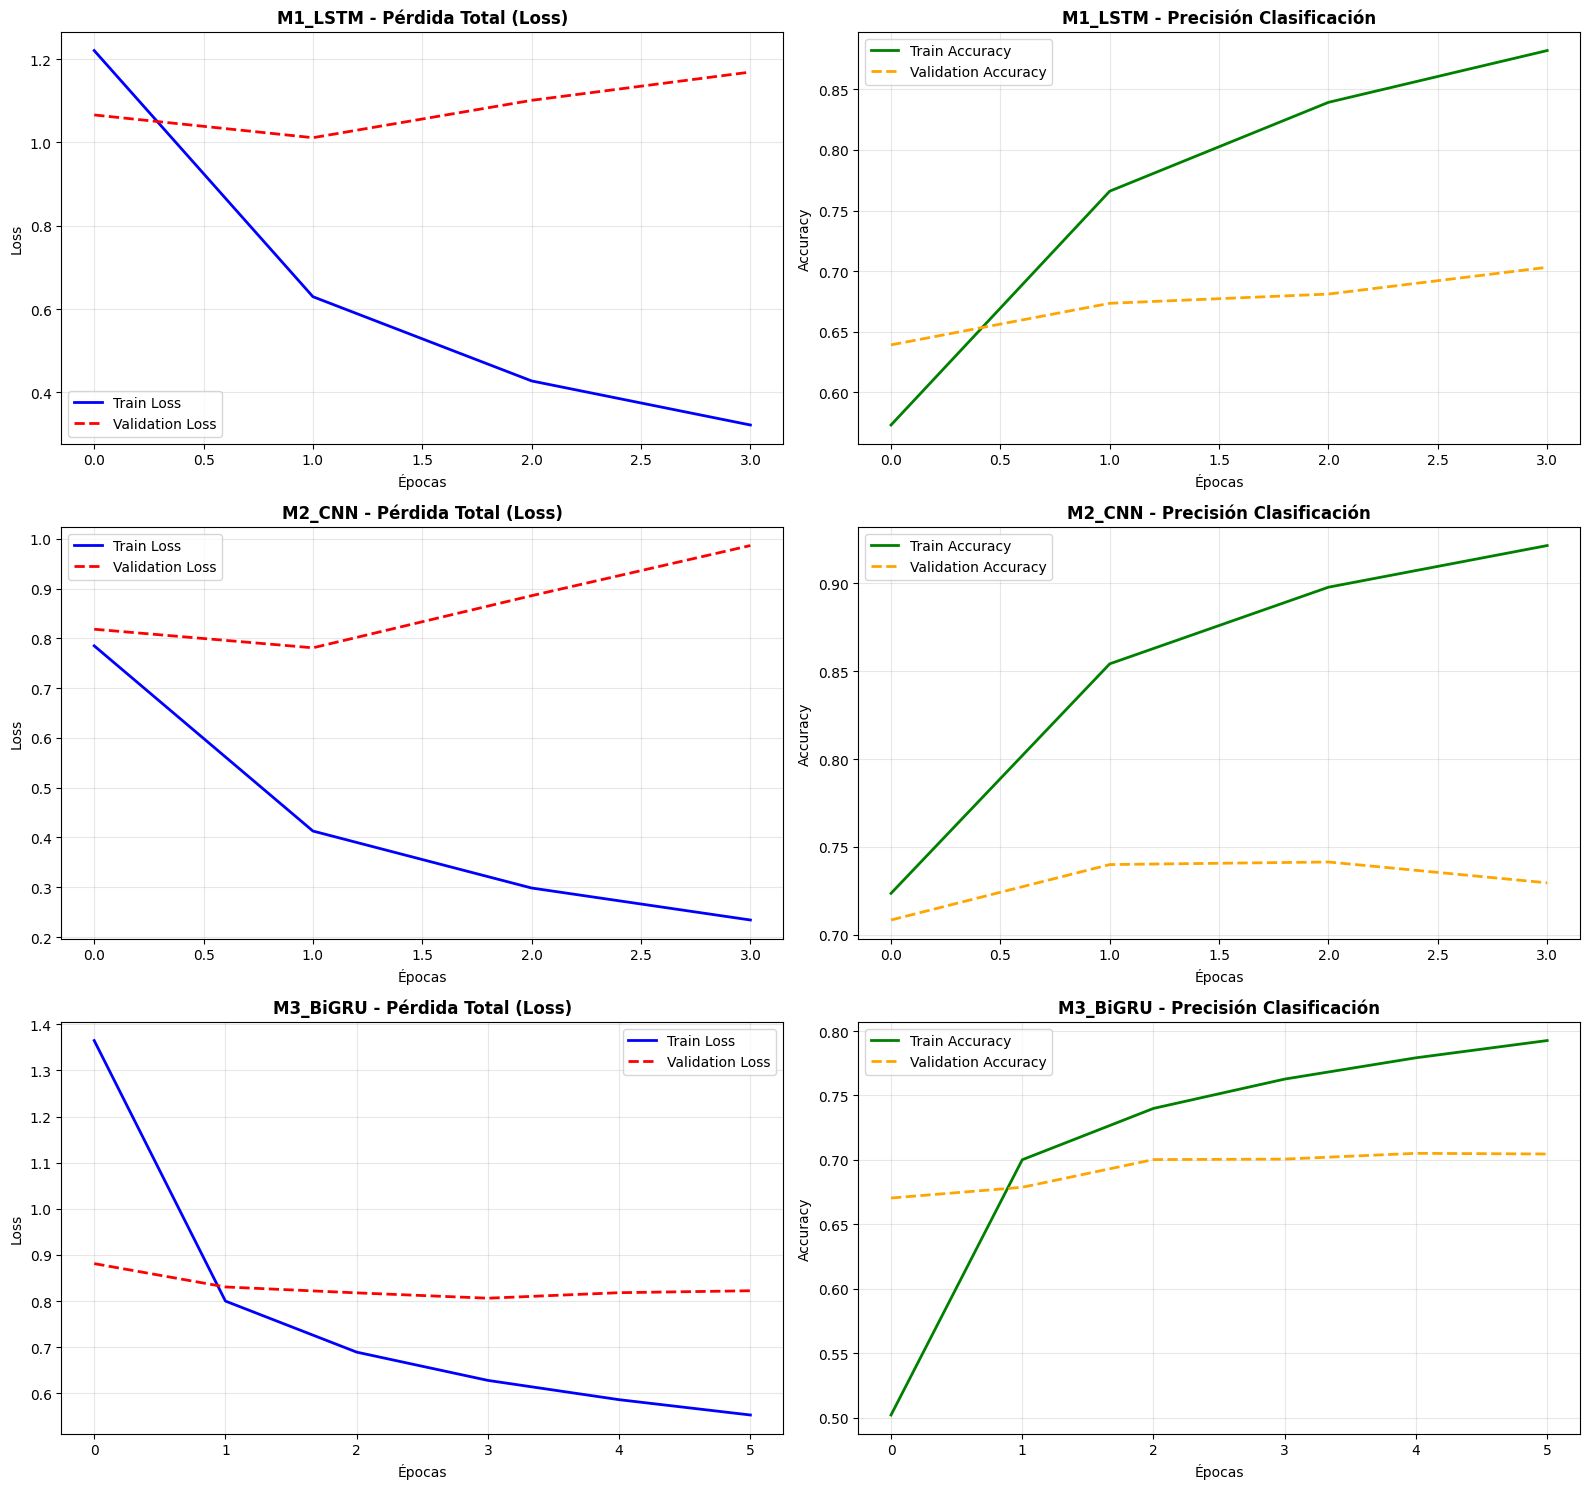


🎯 MÉTRICAS DE VALIDACIÓN EN CLASIFICACIÓN (ENSEMBLE)
              precision    recall  f1-score   support

      ALTICA     0.9791    0.7791    0.8677      1983
   BLACK_ROT     0.7800    0.6663    0.7187     31774
    BOTRYTIS     0.6422    0.4724    0.5444     31647
    EMPOASCA     0.9574    0.9902    0.9735     22355
    ERINOSIS     0.5563    0.4296    0.4849     11100
        ESCA     0.8594    0.9652    0.9092     22482
     HEALTHY     0.8699    0.9272    0.8976     32917
     LOBESIA     0.6793    0.8044    0.7366     21912
      MILDIU     0.3434    0.5494    0.4227     13864
       OIDIO     0.9534    0.9026    0.9273      4755
    RED_MITE     0.8634    0.4755    0.6132      4135

    accuracy                         0.7455    198924
   macro avg     0.7713    0.7238    0.7360    198924
weighted avg     0.7558    0.7455    0.7433    198924



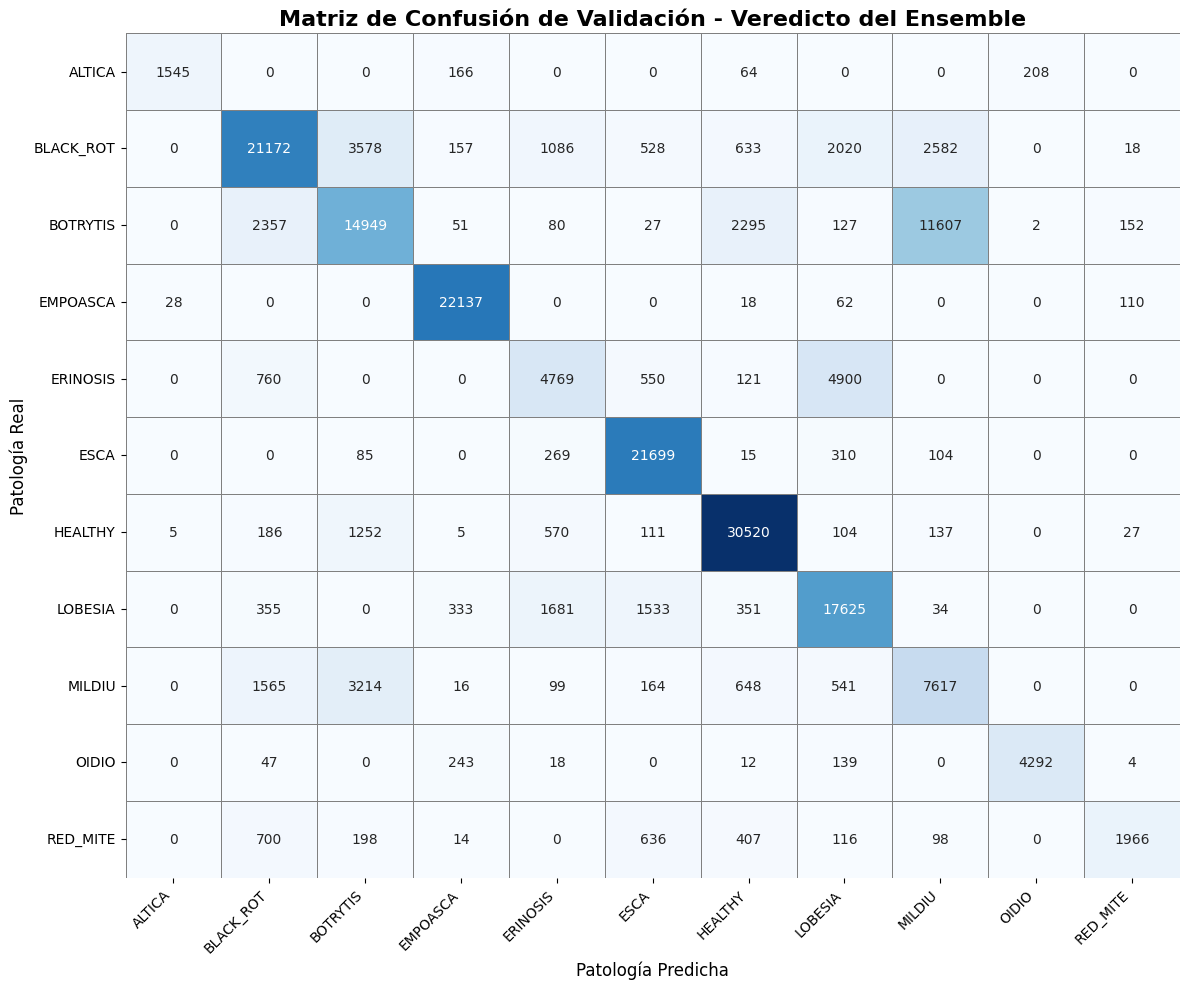


📈 MÉTRICAS DE REGRESIÓN (ENSEMBLE)
MAE  (Mean Absolute Error):      0.0637  (Error medio absoluto en la predicción del daño 0-1)
MSE  (Mean Squared Error):       0.0093  (Penaliza errores grandes)
RMSE (Root Mean Squared Error):  0.0962  (Error estándar en las mismas unidades que la salida)
R2   (Coeficiente Determinación): 0.8747  (Varianza explicada por el modelo. Max 1.0)
EVALUACIÓN DE RENDIMIENTO INDIVIDUAL POR MODELO EN VALIDACIÓN

--------------------------------------------------
🧠 Evaluando modelo: M1_LSTM
--------------------------------------------------
🎯 Métricas de Clasificación:
  - Accuracy:  0.6735 (Precisión global)
  - Precision: 0.6596 (Media Macro)
  - Recall:    0.6549 (Media Macro)
  - F1-Score:  0.6497 (Media Macro)

📈 Métricas de Regresión:
  - MAE:  0.0815
  - RMSE: 0.1212
  - R2:   0.8012

--------------------------------------------------
🧠 Evaluando modelo: M2_CNN
--------------------------------------------------
🎯 Métricas de Clasificación:
  - Accuracy: 

,Accuracy,F1-Score,MAE,R2
M1_LSTM,0.6735,0.6497,0.0815,0.8012
M2_CNN,0.7399,0.7296,0.0711,0.8362
M3_BiGRU,0.7006,0.6757,0.0760,0.8376


In [7]:
# CARGA DE PREPROCESADORES
# ==============================================================================
scaler = joblib.load("pruebas/window10dias/scaler.pkl")
le = joblib.load("pruebas/window10dias/label_encoder.pkl")
print("✅ Preprocesadores (Scaler y LabelEncoder) cargados correctamente.")

# CARGA DE MODELOS
# ==============================================================================
m1_lstm = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_LSTM)
m2_cnn = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_CNN)
m3_bigru = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_BI_GRU)

modelos = [m1_lstm, m2_cnn, m3_bigru]
print("✅ Modelos cargados correctamente.")

# CARGA DE HISTORIALES
# ==============================================================================
historiales = []

for modelo in modelos:
    ruta_historial = RUTA_MODELS_DIR / f"history_{modelo.name}.pkl"
    with open(ruta_historial, 'rb') as f:
        historial = pickle.load(f)
        historiales.append(historial)
    print(f"📊 Historial de {modelo.name} cargado con éxito.")

print("\n🚀 ¡Todos los artefactos y modelos han sido cargados y están listos para usarse!")

# ==============================================================================
# LÓGICA DE INFERENCIA DEL ENSEMBLE (SOFT VOTING & AVERAGING)
# ==============================================================================
def predecir_ensemble(X_input, modelos_ensemble, label_encoder):
    """
    X_input: Tensor de entrada con shape (N, WINDOW_SIZE, 12)
    modelos_ensemble: Lista con los 3 modelos entrenados
    """
    preds_clases_prob = []
    preds_regresion = []
    
    # 1. Obtener predicciones crudas de cada modelo
    for mod in modelos_ensemble:
        p_class, p_reg = mod.predict(X_input, batch_size=512, verbose=0)
        preds_clases_prob.append(p_class) # Probabilidades de Softmax
        preds_regresion.append(p_reg)     # Valores 0-1 de Sigmoide
        
    # 2. SOFT VOTING (Clasificación): Media de las probabilidades
    media_probs = np.mean(preds_clases_prob, axis=0)
    clases_finales_idx = np.argmax(media_probs, axis=1)
    confianza_final = np.max(media_probs, axis=1)
    nombres_clases = label_encoder.inverse_transform(clases_finales_idx)
    
    # 3. SIMPLE AVERAGING (Regresión): Media del grado de infección
    grado_final = np.mean(preds_regresion, axis=0).flatten()
    
    return nombres_clases, grado_final, confianza_final

# --- PRUEBA DEL ENSEMBLE SOBRE DATOS DE VALIDACIÓN ---
print("\n🧪 Evaluando Ensemble sobre los datos de Validación...")
pred_clase, pred_grado, pred_confianza = predecir_ensemble(X_val, modelos, le)

# ==============================================================================
# EVALUACIÓN VISUAL Y MÉTRICAS DE VALIDACIÓN
# ==============================================================================

# --- 1. GRÁFICAS DE PÉRDIDA (LEARNING CURVES) ---
print("📊 Generando curvas de aprendizaje para auditar el sobreajuste (Overfitting)...")

fig, axes = plt.subplots(len(historiales), 2, figsize=(16, 5 * len(historiales)))

for i, (hist, modelo) in enumerate(zip(historiales, modelos)):
    # Gráfica de Pérdida Total (Loss)
    axes[i, 0].plot(hist['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[i, 0].plot(hist['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
    axes[i, 0].set_title(f'{modelo.name} - Pérdida Total (Loss)', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].set_xlabel('Épocas')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    # Gráfica de Precisión de Clasificación (Accuracy)
    # Keras nombra las métricas combinando el nombre de la capa de salida
    acc_key = 'out_class_accuracy' if 'out_class_accuracy' in hist else 'accuracy'
    val_acc_key = 'val_out_class_accuracy' if 'val_out_class_accuracy' in hist else 'val_accuracy'
    
    if acc_key in hist:
        axes[i, 1].plot(hist[acc_key], label='Train Accuracy', color='green', linewidth=2)
        axes[i, 1].plot(hist[val_acc_key], label='Validation Accuracy', color='orange', linestyle='--', linewidth=2)
        axes[i, 1].set_title(f'{modelo.name} - Precisión Clasificación', fontsize=12, fontweight='bold')
        axes[i, 1].set_ylabel('Accuracy')
        axes[i, 1].set_xlabel('Épocas')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 2. MÉTRICAS DE CLASIFICACIÓN (QUÉ PATOLOGÍA ES) ---
print("\n" + "="*50)
print("🎯 MÉTRICAS DE VALIDACIÓN EN CLASIFICACIÓN (ENSEMBLE)")
print("="*50)

y_val_real_nombres = le.inverse_transform(y_val_class)

# Classification Report (Incluye Precision, Recall, F1-Score y Accuracy Macro)
reporte = classification_report(y_val_real_nombres, pred_clase, digits=4)
print(reporte)

# Matriz de Confusión
cm = confusion_matrix(y_val_real_nombres, pred_clase, labels=le.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar=False, linewidths=0.5, linecolor='gray')
plt.title('Matriz de Confusión de Validación - Veredicto del Ensemble', fontsize=16, fontweight='bold')
plt.ylabel('Patología Real', fontsize=12)
plt.xlabel('Patología Predicha', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 3. MÉTRICAS DE REGRESIÓN (CUÁNTO DAÑO HAY) ---
print("\n" + "="*50)
print("📈 MÉTRICAS DE REGRESIÓN (ENSEMBLE)")
print("="*50)

mae = mean_absolute_error(y_val_reg, pred_grado)
mse = mean_squared_error(y_val_reg, pred_grado)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_reg, pred_grado)

print(f"MAE  (Mean Absolute Error):      {mae:.4f}  (Error medio absoluto en la predicción del daño 0-1)")
print(f"MSE  (Mean Squared Error):       {mse:.4f}  (Penaliza errores grandes)")
print(f"RMSE (Root Mean Squared Error):  {rmse:.4f}  (Error estándar en las mismas unidades que la salida)")
print(f"R2   (Coeficiente Determinación): {r2:.4f}  (Varianza explicada por el modelo. Max 1.0)")
print("="*50)

# ==============================================================================
# EVALUACIÓN INDIVIDUAL POR MODELO (LSTM, CNN, BiGRU)
# ==============================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*60)
print("EVALUACIÓN DE RENDIMIENTO INDIVIDUAL POR MODELO EN VALIDACIÓN")
print("="*60)

# Convertimos las etiquetas reales a sus nombres en texto para la matriz de confusión
y_val_real_nombres = le.inverse_transform(y_val_class)

# Diccionario para ir guardando un resumen y poder comparar al final
resumen_metricas = {}

for modelo in modelos:
    print(f"\n" + "-" * 50)
    print(f"🧠 Evaluando modelo: {modelo.name}")
    print("-" * 50)
    
    # 1. PREDICCIÓN
    # El modelo devuelve dos arrays: probabilidades de clasificación y valores de regresión
    p_class, p_reg = modelo.predict(X_val, batch_size=512, verbose=0)
    
    # Procesamos las salidas
    pred_clases_idx = np.argmax(p_class, axis=1)
    pred_grado = p_reg.flatten()
    pred_clases_nombres = le.inverse_transform(pred_clases_idx)
    
    # 2. MÉTRICAS DE CLASIFICACIÓN (Macro average)
    acc = accuracy_score(y_val_class, pred_clases_idx)
    prec = precision_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    rec = recall_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    f1 = f1_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    
    print(f"🎯 Métricas de Clasificación:")
    print(f"  - Accuracy:  {acc:.4f} (Precisión global)")
    print(f"  - Precision: {prec:.4f} (Media Macro)")
    print(f"  - Recall:    {rec:.4f} (Media Macro)")
    print(f"  - F1-Score:  {f1:.4f} (Media Macro)")
    
    # 3. MÉTRICAS DE REGRESIÓN
    mae = mean_absolute_error(y_val_reg, pred_grado)
    rmse = np.sqrt(mean_squared_error(y_val_reg, pred_grado))
    r2 = r2_score(y_val_reg, pred_grado)
    
    print(f"\n📈 Métricas de Regresión:")
    print(f"  - MAE:  {mae:.4f}")
    print(f"  - RMSE: {rmse:.4f}")
    print(f"  - R2:   {r2:.4f}")
    
    # Guardamos en el diccionario para imprimir una tabla resumen luego
    resumen_metricas[modelo.name] = {
        'Accuracy': acc, 'F1-Score': f1, 'MAE': mae, 'R2': r2
    }
    
# ==============================================================================
# TABLA RESUMEN FINAL
# ==============================================================================
print("\n" + "="*60)
print("📊 RESUMEN COMPARATIVO DE LOS MODELOS")
print("="*60)
df_resumen = pd.DataFrame(resumen_metricas).T
display(df_resumen.round(4))

## **Tamaño de la Ventana: 2 semanas**

In [ ]:
# =========================================================
# CONFIGURACIONES DEL MODELO:
# =========================================================
DIAS_CONTEXTO = 14
WINDOW_SIZE = DIAS_CONTEXTO * 24    # Horas de contexto
BATCH_SIZE = 512   # Memoria
EPOCHS = 50         # Epocas de entrenamiento
EARLY_STOPPING = 2  # Patience

# ==========================================================
# CARGA DE DATOS:
# ==========================================================
df = pd.read_parquet("../../data/processed/data_vin_processed.parquet")

# ==========================================================
# PREPROCESAMIENTO:
# ==========================================================
# Orden alfabético
df = df.reindex(sorted(df.columns), axis=1)

# Asegurar tipos string para evitar errores en el modelo:
cols_str = ['Etiqueta_Clase', 'Clase_Entrenamiento']
for col in cols_str:
    if col in df.columns:
        df[col] = df[col].astype(str)

# 1. CODIFICACIÓN DE TARGETS
le = LabelEncoder()
# TARGET: El estado real en ese instante temporal
df['Etiqueta_Num'] = le.fit_transform(df['Clase_Entrenamiento']) 
print(f"✅ Clases codificadas: {dict(zip(le.classes_, range(len(le.classes_))))}")

# 2. SELECCIÓN DE VARIABLES
# Quitamos Fecha (ya no sirve a la red), ID_Serie (no es predictiva) y Etiquetas crudas
cols_features = [
    'Temp_Amb_C', 
    'Hum_Rel_Pct', 'Lluvia_mm', 'Viento_kmh', 
    'Horas_Humedad_Foliar', 'GDD_Acumulado', 
    'Hum_Suelo_Pct', 'pH_Suelo',
    'Hora_Sin', 'Hora_Cos',
    'CO2_ppm', 'VOC_ppb'
]

target_class = 'Etiqueta_Num'
target_reg = 'Grado_Infeccion'

# 3. SPLIT ESTRATÉGICO ESTRATIFICADO (POR ID_SERIE, NUNCA ALEATORIO POR FILA)
# Obtenemos un diccionario 1 a 1 de cada ID_Serie con su patología general
df_unicos = df.drop_duplicates(subset=['ID_Serie'])[['ID_Serie', 'Etiqueta_Clase']]

ids = df_unicos['ID_Serie']
etiquetas = df_unicos['Etiqueta_Clase']

# Primer Split: 70% Train, 30% Temp (Estratificado por la etiqueta)
train_ids, temp_ids, _, temp_etiquetas = train_test_split(
    ids, etiquetas, 
    test_size=0.30, 
    random_state=42, 
    stratify=etiquetas
)

# Segundo Split: Dividimos el 30% restante en 15% Val y 15% Test
val_ids, test_ids = train_test_split(
    temp_ids, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_etiquetas
)

# Reconstruimos los DataFrames completos usando los IDs seleccionados
train_df = df[df['ID_Serie'].isin(train_ids)].copy()
val_df = df[df['ID_Serie'].isin(val_ids)].copy()
test_df = df[df['ID_Serie'].isin(test_ids)].copy()

print(f"📊 Series separadas -> Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

# 4. ESCALADO
scaler = StandardScaler()
# Ajustamos solo en train para evitar fuga de datos
scaler.fit(train_df[cols_features])

# Transformamos todos
train_df[cols_features] = scaler.transform(train_df[cols_features])
val_df[cols_features] = scaler.transform(val_df[cols_features])
test_df[cols_features] = scaler.transform(test_df[cols_features])
print("✅ Datos escalados correctamente.")

# 5. GENERACIÓN DE VENTANAS TEMPORALES (MEMORIA OPTIMIZADA)
def crear_secuencias(df_part, window_size, features, t_class, t_reg):
    X, y_c, y_r = [], [], []
    grupos = df_part.groupby('ID_Serie')
    
    for _, grupo in tqdm(grupos, desc="Generando tensores", leave=False):
        data_features = grupo[features].values
        data_class = grupo[t_class].values
        data_reg = grupo[t_reg].values
        
        # Deslizamiento de ventana
        for i in range(len(data_features) - window_size):
            X.append(data_features[i : i + window_size])
            # El target es el estado al FINAL de la ventana
            y_c.append(data_class[i + window_size])
            y_r.append(data_reg[i + window_size])
            
    return np.array(X, dtype=np.float32), np.array(y_c, dtype=np.int8), np.array(y_r, dtype=np.float32)

print("\n🚀 Empaquetando tensores 3D (Esto tomará un minuto)...")
X_train, y_train_class, y_train_reg = crear_secuencias(train_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_val, y_val_class, y_val_reg = crear_secuencias(val_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_test, y_test_class, y_test_reg = crear_secuencias(test_df, WINDOW_SIZE, cols_features, target_class, target_reg)

# Limpiar RAM
del train_df, val_df, test_df
gc.collect()

# ==============================================================================
# DEEP ENSEMBLE LEARNING: DEFINICIÓN DE LAS 3 REDES
# ==============================================================================
NUM_FEATURES = len(cols_features)  # 12
NUM_CLASSES = len(le.classes_)     # 11
tf.keras.utils.set_random_seed(42)

def compilar_modelo(modelo, lr):
    modelo.compile(
        optimizer=Adam(learning_rate=lr),
        loss={"out_class": "sparse_categorical_crossentropy", "out_reg": "mse"},
        loss_weights={"out_class": 1.0, "out_reg": 1.0},
        metrics={"out_class": ["accuracy"], "out_reg": ["mae"]}
    )
    return modelo

# --- MODELO 1: LSTM PURA ---
def build_lstm_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M1")
    x = LSTM(32, return_sequences=True)(inp)  
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)                       
    x = LSTM(16)(x)                           
    x = BatchNormalization()(x)
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M1_LSTM"), lr=0.001)

# --- MODELO 2: CNN-1D ---
def build_cnn_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M2")
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inp)
    x = BatchNormalization()(x)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)                                                           
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M2_CNN"), lr=0.001)

# --- MODELO 3: GRU BIDIRECCIONAL ---
def build_bigru_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M3")
    x = Bidirectional(GRU(16, return_sequences=False))(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(16, activation='relu')(x)
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M3_BiGRU"), lr=0.001)

# Instanciamos los 3 modelos
m1_lstm = build_lstm_model()
m2_cnn = build_cnn_model()
m3_bigru = build_bigru_model()

✅ Clases codificadas: {'ALTICA': 0, 'BLACK_ROT': 1, 'BOTRYTIS': 2, 'EMPOASCA': 3, 'ERINOSIS': 4, 'ESCA': 5, 'HEALTHY': 6, 'LOBESIA': 7, 'MILDIU': 8, 'OIDIO': 9, 'RED_MITE': 10}
📊 Series separadas -> Train: 692 | Val: 148 | Test: 149
✅ Datos escalados correctamente.

🚀 Empaquetando tensores 3D (Esto tomará un minuto)...


In [9]:
# ==============================================================================
# ENTRENAMIENTO DEL ENSEMBLE Y GUARDADO DE ARTEFACTOS
# ==============================================================================

RUTA_MODELS_DIR = Path("pruebas/window2sem/")
NOMBRE_MODELO_LSTM = "M1_LSTM.keras"
NOMBRE_MODELO_CNN = "M2_CNN.keras"
NOMBRE_MODELO_BI_GRU = "M3_BiGRU.keras"

# 1. Guardar los preprocesadores inmediatamente de forma segura
joblib.dump(scaler, "pruebas/window2sem/scaler.pkl")
joblib.dump(le, "pruebas/window2sem/label_encoder.pkl")
print("Preprocesadores guardados en: pruebas/window2sem/")

modelos = [m1_lstm, m2_cnn, m3_bigru]
historiales = []

print("\nIniciando entrenamiento secuencial de redes: ", len(modelos))

start_time_total = time.time()      # INICIO DE CRONÓMETRO TOTAL

for i, modelo in enumerate(modelos):
    print("\n" + "="*50)
    print("Entrenando Modelo: ", modelo.name)
    print("="*50)
    
    start_time_model = time.time()  # INICIO DE CRONÓMETRO MODELO

    # Pre-definimos la ruta donde se guardara ESTE modelo en concreto
    ruta_modelo = RUTA_MODELS_DIR / f"{modelo.name}.keras"
    
    # Instanciamos los Callbacks desde cero para que no crucen historial entre redes
    early_stop_individual = EarlyStopping(
        monitor='val_loss', 
        patience=EARLY_STOPPING, 
        restore_best_weights=True,
        verbose=1
    )
    
    checkpoint_individual = ModelCheckpoint(
        filepath=ruta_modelo,
        monitor='val_loss',        # Vigilamos la perdida de validacion global
        save_best_only=True,       # Solo sobreescribe si la red mejora en esta epoca
        mode='min',                # Queremos minimizar el val_loss
        verbose=1
    )
    
    # Inicia el entrenamiento (Fit)
    hist = modelo.fit(
        X_train, 
        {"out_class": y_train_class, "out_reg": y_train_reg},
        validation_data=(X_val, {"out_class": y_val_class, "out_reg": y_val_reg}),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop_individual, checkpoint_individual],
        verbose=1
    )
    
    # La red (.keras) ya ha sido guardada en su mejor punto por el Checkpoint.
    # Ahora solo necesitamos guardar el historial de la funcion de perdida.
    ruta_historial = RUTA_MODELS_DIR / f"history_{modelo.name}.pkl"
    with open(ruta_historial, 'wb') as f:
        pickle.dump(hist.history, f)
        
    historiales.append(hist.history)
    print("Historial guardado con exito: ", modelo.name)

    end_time_model = time.time()    # FIN DE CRONÓMETRO MODELO
    elapsed_model_mins = (end_time_model - start_time_model) / 60.0
    print(f"⏱️ Tiempo de entrenamiento para {modelo.name}: {elapsed_model_mins:.2f} minutos.")

end_time_total = time.time()        # FIN DE CRONÓMETRO TOTAL
elapsed_total_mins = (end_time_total - start_time_total) / 60.0
print(f"\n⏱️ TIEMPO TOTAL DE ENTRENAMIENTO DEL ENSEMBLE: {elapsed_total_mins:.2f} minutos.")

print("\nENTRENAMIENTO Y EXPORTACION COMPLETADOS. Todos los archivos estan seguros en: ", RUTA_MODELS_DIR.resolve())

Preprocesadores guardados en: pruebas/window2sem/

Iniciando entrenamiento secuencial de redes:  3

Entrenando Modelo:  M1_LSTM
Epoch 1/50
1787/1787 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - loss: 1.4384 - out_class_accuracy: 0.5109 - out_class_loss: 1.3914 - out_reg_loss: 0.0470 - out_reg_mae: 0.1570
Epoch 1: val_loss improved from None to 1.09282, saving model to pruebas\window2sem\M1_LSTM.keras
1787/1787 ━━━━━━━━━━━━━━━━━━━━ 623s 348ms/step - loss: 1.0360 - out_class_accuracy: 0.6387 - out_class_loss: 1.0084 - out_reg_loss: 0.0275 - out_reg_mae: 0.1151 - val_loss: 1.0928 - val_out_class_accuracy: 0.6475 - val_out_class_loss: 1.0724 - val_out_reg_loss: 0.0190 - val_out_reg_mae: 0.0912
Epoch 2/50
1787/1787 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - loss: 0.6177 - out_class_accuracy: 0.7750 - out_class_loss: 0.6010 - out_reg_loss: 0.0166 - out_reg_mae: 0.0883
Epoch 2: val_loss improved from 1.09282 to 0.98227, saving model to pruebas\window2sem\M1_LSTM.keras
1787/1787 ━━━━━━━━━━━━━━━━━━━━ 637s 35

✅ Preprocesadores (Scaler y LabelEncoder) cargados correctamente.
✅ Modelos cargados correctamente.
📊 Historial de M1_LSTM cargado con éxito.
📊 Historial de M2_CNN cargado con éxito.
📊 Historial de M3_BiGRU cargado con éxito.

🚀 ¡Todos los artefactos y modelos han sido cargados y están listos para usarse!

🧪 Evaluando Ensemble sobre los datos de Validación...
📊 Generando curvas de aprendizaje para auditar el sobreajuste (Overfitting)...


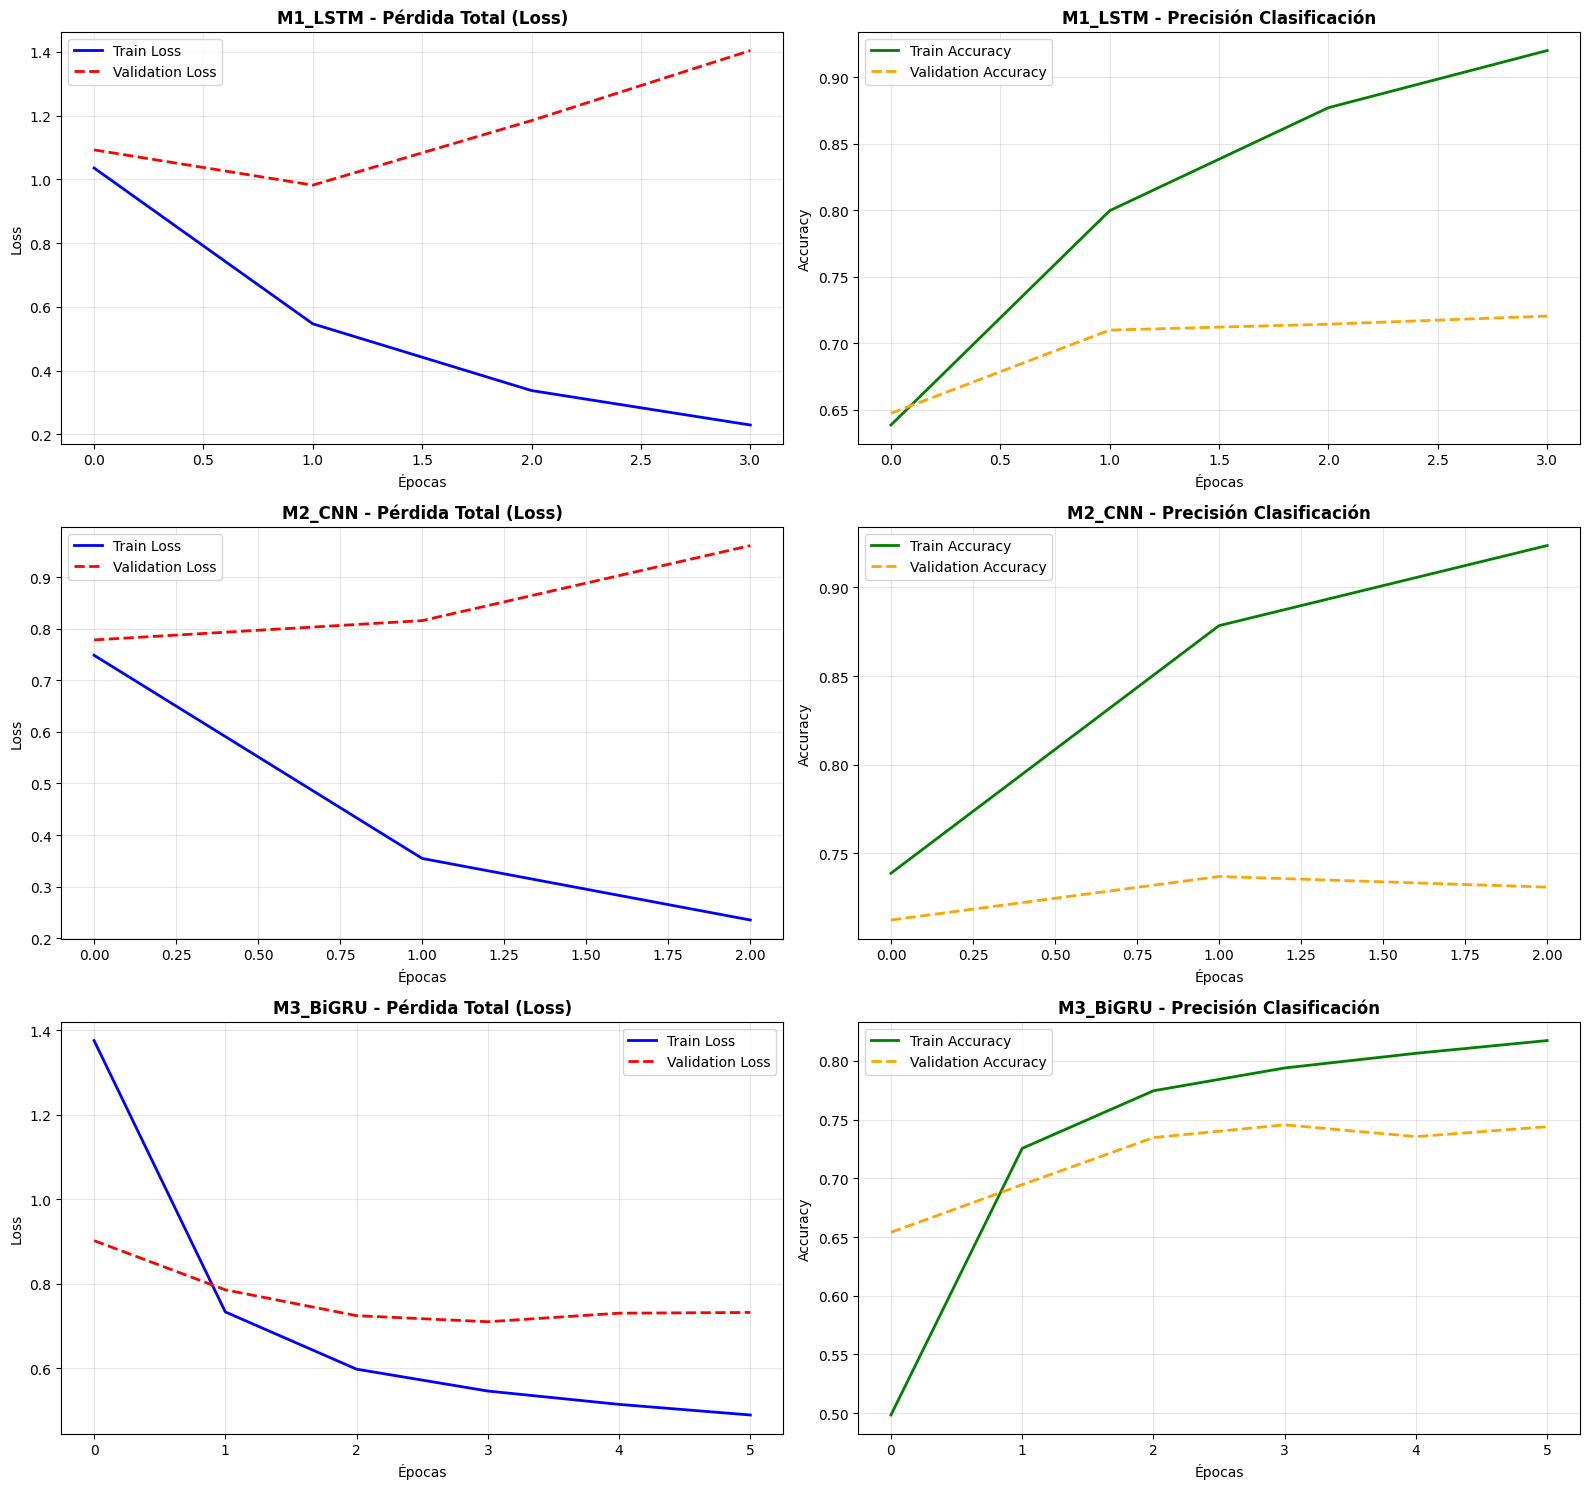


🎯 MÉTRICAS DE VALIDACIÓN EN CLASIFICACIÓN (ENSEMBLE)
              precision    recall  f1-score   support

      ALTICA     1.0000    0.3070    0.4698       710
   BLACK_ROT     0.7689    0.7113    0.7390     31102
    BOTRYTIS     0.6441    0.5298    0.5814     31071
    EMPOASCA     0.9695    0.9991    0.9841     21107
    ERINOSIS     0.5910    0.7016    0.6416     10017
        ESCA     0.9012    0.9502    0.9250     20963
     HEALTHY     0.8837    0.9163    0.8997     28961
     LOBESIA     0.7288    0.7950    0.7605     21336
      MILDIU     0.3358    0.4238    0.3747     12808
       OIDIO     0.8970    0.8873    0.8921      3603
    RED_MITE     0.9474    0.4879    0.6441      3398

    accuracy                         0.7598    185076
   macro avg     0.7879    0.7008    0.7193    185076
weighted avg     0.7662    0.7598    0.7589    185076



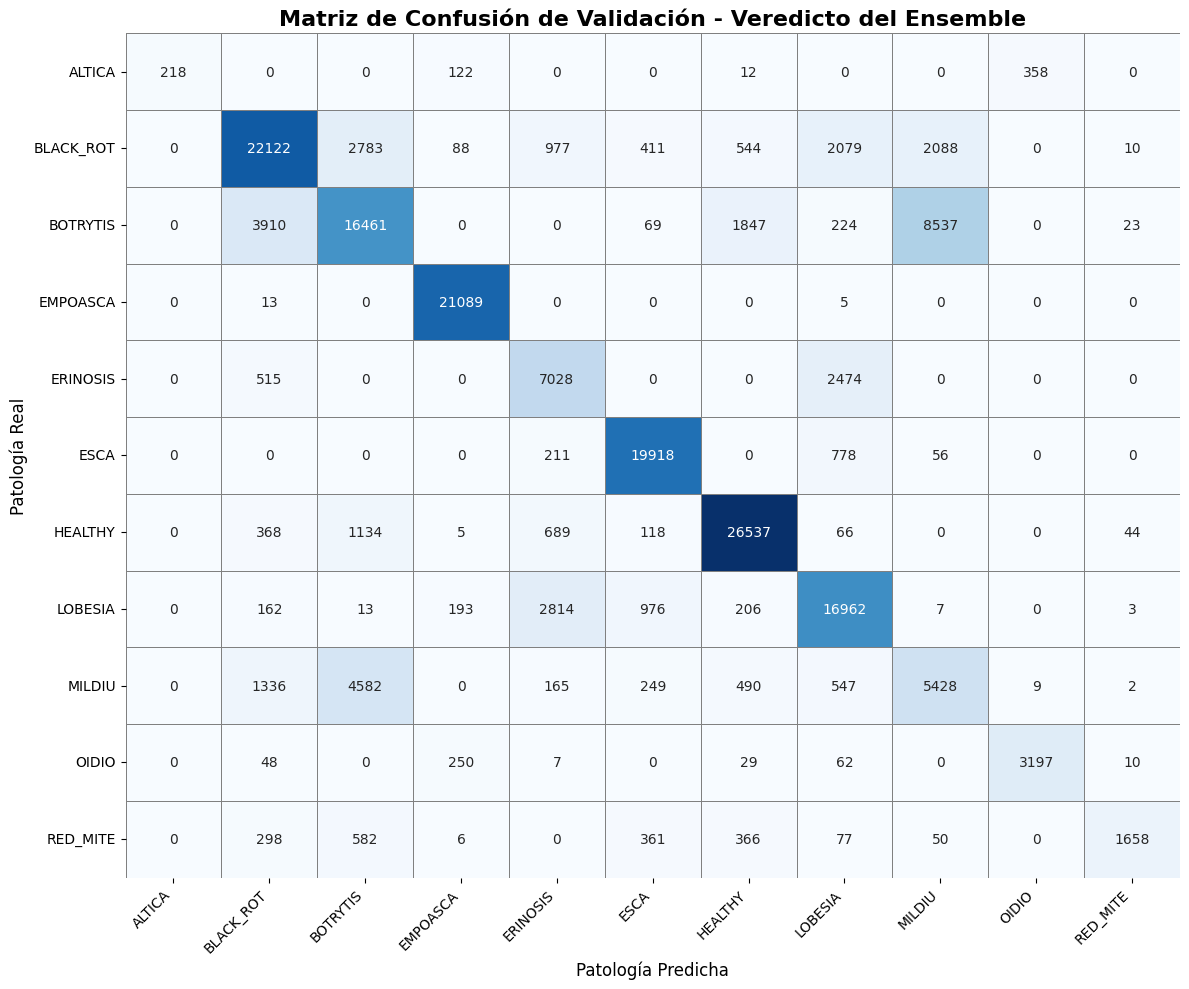


📈 MÉTRICAS DE REGRESIÓN (ENSEMBLE)
MAE  (Mean Absolute Error):      0.0675  (Error medio absoluto en la predicción del daño 0-1)
MSE  (Mean Squared Error):       0.0103  (Penaliza errores grandes)
RMSE (Root Mean Squared Error):  0.1013  (Error estándar en las mismas unidades que la salida)
R2   (Coeficiente Determinación): 0.8611  (Varianza explicada por el modelo. Max 1.0)
EVALUACIÓN DE RENDIMIENTO INDIVIDUAL POR MODELO EN VALIDACIÓN

--------------------------------------------------
🧠 Evaluando modelo: M1_LSTM
--------------------------------------------------
🎯 Métricas de Clasificación:
  - Accuracy:  0.7101 (Precisión global)
  - Precision: 0.7125 (Media Macro)
  - Recall:    0.6628 (Media Macro)
  - F1-Score:  0.6780 (Media Macro)

📈 Métricas de Regresión:
  - MAE:  0.0828
  - RMSE: 0.1233
  - R2:   0.7944

--------------------------------------------------
🧠 Evaluando modelo: M2_CNN
--------------------------------------------------
🎯 Métricas de Clasificación:
  - Accuracy: 

,Accuracy,F1-Score,MAE,R2
M1_LSTM,0.7101,0.6780,0.0828,0.7944
M2_CNN,0.7124,0.6596,0.0823,0.7971
M3_BiGRU,0.7455,0.7044,0.0800,0.8224


In [10]:
# CARGA DE PREPROCESADORES
# ==============================================================================
scaler = joblib.load("pruebas/window2sem/scaler.pkl")
le = joblib.load("pruebas/window2sem/label_encoder.pkl")
print("✅ Preprocesadores (Scaler y LabelEncoder) cargados correctamente.")

# CARGA DE MODELOS
# ==============================================================================
m1_lstm = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_LSTM)
m2_cnn = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_CNN)
m3_bigru = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_BI_GRU)

modelos = [m1_lstm, m2_cnn, m3_bigru]
print("✅ Modelos cargados correctamente.")

# CARGA DE HISTORIALES
# ==============================================================================
historiales = []

for modelo in modelos:
    ruta_historial = RUTA_MODELS_DIR / f"history_{modelo.name}.pkl"
    with open(ruta_historial, 'rb') as f:
        historial = pickle.load(f)
        historiales.append(historial)
    print(f"📊 Historial de {modelo.name} cargado con éxito.")

print("\n🚀 ¡Todos los artefactos y modelos han sido cargados y están listos para usarse!")

# ==============================================================================
# LÓGICA DE INFERENCIA DEL ENSEMBLE (SOFT VOTING & AVERAGING)
# ==============================================================================
def predecir_ensemble(X_input, modelos_ensemble, label_encoder):
    """
    X_input: Tensor de entrada con shape (N, WINDOW_SIZE, 12)
    modelos_ensemble: Lista con los 3 modelos entrenados
    """
    preds_clases_prob = []
    preds_regresion = []
    
    # 1. Obtener predicciones crudas de cada modelo
    for mod in modelos_ensemble:
        p_class, p_reg = mod.predict(X_input, batch_size=512, verbose=0)
        preds_clases_prob.append(p_class) # Probabilidades de Softmax
        preds_regresion.append(p_reg)     # Valores 0-1 de Sigmoide
        
    # 2. SOFT VOTING (Clasificación): Media de las probabilidades
    media_probs = np.mean(preds_clases_prob, axis=0)
    clases_finales_idx = np.argmax(media_probs, axis=1)
    confianza_final = np.max(media_probs, axis=1)
    nombres_clases = label_encoder.inverse_transform(clases_finales_idx)
    
    # 3. SIMPLE AVERAGING (Regresión): Media del grado de infección
    grado_final = np.mean(preds_regresion, axis=0).flatten()
    
    return nombres_clases, grado_final, confianza_final

# --- PRUEBA DEL ENSEMBLE SOBRE DATOS DE VALIDACIÓN ---
print("\n🧪 Evaluando Ensemble sobre los datos de Validación...")
pred_clase, pred_grado, pred_confianza = predecir_ensemble(X_val, modelos, le)

# ==============================================================================
# EVALUACIÓN VISUAL Y MÉTRICAS DE VALIDACIÓN
# ==============================================================================

# --- 1. GRÁFICAS DE PÉRDIDA (LEARNING CURVES) ---
print("📊 Generando curvas de aprendizaje para auditar el sobreajuste (Overfitting)...")

fig, axes = plt.subplots(len(historiales), 2, figsize=(16, 5 * len(historiales)))

for i, (hist, modelo) in enumerate(zip(historiales, modelos)):
    # Gráfica de Pérdida Total (Loss)
    axes[i, 0].plot(hist['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[i, 0].plot(hist['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
    axes[i, 0].set_title(f'{modelo.name} - Pérdida Total (Loss)', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].set_xlabel('Épocas')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    # Gráfica de Precisión de Clasificación (Accuracy)
    # Keras nombra las métricas combinando el nombre de la capa de salida
    acc_key = 'out_class_accuracy' if 'out_class_accuracy' in hist else 'accuracy'
    val_acc_key = 'val_out_class_accuracy' if 'val_out_class_accuracy' in hist else 'val_accuracy'
    
    if acc_key in hist:
        axes[i, 1].plot(hist[acc_key], label='Train Accuracy', color='green', linewidth=2)
        axes[i, 1].plot(hist[val_acc_key], label='Validation Accuracy', color='orange', linestyle='--', linewidth=2)
        axes[i, 1].set_title(f'{modelo.name} - Precisión Clasificación', fontsize=12, fontweight='bold')
        axes[i, 1].set_ylabel('Accuracy')
        axes[i, 1].set_xlabel('Épocas')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 2. MÉTRICAS DE CLASIFICACIÓN (QUÉ PATOLOGÍA ES) ---
print("\n" + "="*50)
print("🎯 MÉTRICAS DE VALIDACIÓN EN CLASIFICACIÓN (ENSEMBLE)")
print("="*50)

y_val_real_nombres = le.inverse_transform(y_val_class)

# Classification Report (Incluye Precision, Recall, F1-Score y Accuracy Macro)
reporte = classification_report(y_val_real_nombres, pred_clase, digits=4)
print(reporte)

# Matriz de Confusión
cm = confusion_matrix(y_val_real_nombres, pred_clase, labels=le.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar=False, linewidths=0.5, linecolor='gray')
plt.title('Matriz de Confusión de Validación - Veredicto del Ensemble', fontsize=16, fontweight='bold')
plt.ylabel('Patología Real', fontsize=12)
plt.xlabel('Patología Predicha', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 3. MÉTRICAS DE REGRESIÓN (CUÁNTO DAÑO HAY) ---
print("\n" + "="*50)
print("📈 MÉTRICAS DE REGRESIÓN (ENSEMBLE)")
print("="*50)

mae = mean_absolute_error(y_val_reg, pred_grado)
mse = mean_squared_error(y_val_reg, pred_grado)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_reg, pred_grado)

print(f"MAE  (Mean Absolute Error):      {mae:.4f}  (Error medio absoluto en la predicción del daño 0-1)")
print(f"MSE  (Mean Squared Error):       {mse:.4f}  (Penaliza errores grandes)")
print(f"RMSE (Root Mean Squared Error):  {rmse:.4f}  (Error estándar en las mismas unidades que la salida)")
print(f"R2   (Coeficiente Determinación): {r2:.4f}  (Varianza explicada por el modelo. Max 1.0)")
print("="*50)

# ==============================================================================
# EVALUACIÓN INDIVIDUAL POR MODELO (LSTM, CNN, BiGRU)
# ==============================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*60)
print("EVALUACIÓN DE RENDIMIENTO INDIVIDUAL POR MODELO EN VALIDACIÓN")
print("="*60)

# Convertimos las etiquetas reales a sus nombres en texto para la matriz de confusión
y_val_real_nombres = le.inverse_transform(y_val_class)

# Diccionario para ir guardando un resumen y poder comparar al final
resumen_metricas = {}

for modelo in modelos:
    print(f"\n" + "-" * 50)
    print(f"🧠 Evaluando modelo: {modelo.name}")
    print("-" * 50)
    
    # 1. PREDICCIÓN
    # El modelo devuelve dos arrays: probabilidades de clasificación y valores de regresión
    p_class, p_reg = modelo.predict(X_val, batch_size=512, verbose=0)
    
    # Procesamos las salidas
    pred_clases_idx = np.argmax(p_class, axis=1)
    pred_grado = p_reg.flatten()
    pred_clases_nombres = le.inverse_transform(pred_clases_idx)
    
    # 2. MÉTRICAS DE CLASIFICACIÓN (Macro average)
    acc = accuracy_score(y_val_class, pred_clases_idx)
    prec = precision_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    rec = recall_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    f1 = f1_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    
    print(f"🎯 Métricas de Clasificación:")
    print(f"  - Accuracy:  {acc:.4f} (Precisión global)")
    print(f"  - Precision: {prec:.4f} (Media Macro)")
    print(f"  - Recall:    {rec:.4f} (Media Macro)")
    print(f"  - F1-Score:  {f1:.4f} (Media Macro)")
    
    # 3. MÉTRICAS DE REGRESIÓN
    mae = mean_absolute_error(y_val_reg, pred_grado)
    rmse = np.sqrt(mean_squared_error(y_val_reg, pred_grado))
    r2 = r2_score(y_val_reg, pred_grado)
    
    print(f"\n📈 Métricas de Regresión:")
    print(f"  - MAE:  {mae:.4f}")
    print(f"  - RMSE: {rmse:.4f}")
    print(f"  - R2:   {r2:.4f}")
    
    # Guardamos en el diccionario para imprimir una tabla resumen luego
    resumen_metricas[modelo.name] = {
        'Accuracy': acc, 'F1-Score': f1, 'MAE': mae, 'R2': r2
    }
    
# ==============================================================================
# TABLA RESUMEN FINAL
# ==============================================================================
print("\n" + "="*60)
print("📊 RESUMEN COMPARATIVO DE LOS MODELOS")
print("="*60)
df_resumen = pd.DataFrame(resumen_metricas).T
display(df_resumen.round(4))

## **Conclusión:**

Debido a la superioridad métrica y eficiencia computacional que presenta la ventana de contexto de 168 horas (1 semana), escogeremos este valor para el modelo DEL final. La tabla de métricas sobre el conjunto de validación del modelo DEL con cada una de las ventanas temporales son las siguientes:

|Tamaño de Ventana | Accuracy | Precisión (Macro) | Recall (Macro) | F1-Score (Macro) | R2 | Tiempo de Entrenamiento |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
|1 semana | 0,7475 | 0,7709 | 0,7306 | 0,7428 | 0,8749 | 46 min |
|10 días  | 0,7455 | 0,7713 | 0,7238 | 0,7360 | 0,8747 | 75 min |
|2 semanas| 0,7598 | 0,7879 | 0,7008 | 0,7193 | 0,8611 | 103 min|

---

# **SELECCIÓN DE SCALER**

## **Standard Scaler**

In [ ]:
# =========================================================
# CONFIGURACIONES DEL MODELO:
# =========================================================
DIAS_CONTEXTO = 7
WINDOW_SIZE = DIAS_CONTEXTO * 24   # Horas de contexto
BATCH_SIZE = 512    # Memoria
EPOCHS = 50         # Epocas de entrenamiento
EARLY_STOPPING = 2  # Patience

# ==========================================================
# CARGA DE DATOS:
# ==========================================================
df = pd.read_parquet("../../data/processed/data_vin_processed.parquet")

# ==========================================================
# PREPROCESAMIENTO:
# ==========================================================
# Orden alfabético
df = df.reindex(sorted(df.columns), axis=1)

# Asegurar tipos string para evitar errores en el modelo:
cols_str = ['Etiqueta_Clase', 'Clase_Entrenamiento']
for col in cols_str:
    if col in df.columns:
        df[col] = df[col].astype(str)

# 1. CODIFICACIÓN DE TARGETS
le = LabelEncoder()
# TARGET: El estado real en ese instante temporal
df['Etiqueta_Num'] = le.fit_transform(df['Clase_Entrenamiento']) 
print(f"✅ Clases codificadas: {dict(zip(le.classes_, range(len(le.classes_))))}")

# 2. SELECCIÓN DE VARIABLES
# Quitamos Fecha (ya no sirve a la red), ID_Serie (no es predictiva) y Etiquetas crudas
cols_features = [
    'Temp_Amb_C', 
    'Hum_Rel_Pct', 'Lluvia_mm', 'Viento_kmh', 
    'Horas_Humedad_Foliar', 'GDD_Acumulado', 
    'Hum_Suelo_Pct', 'pH_Suelo',
    'Hora_Sin', 'Hora_Cos',
    'CO2_ppm', 'VOC_ppb'
]

target_class = 'Etiqueta_Num'
target_reg = 'Grado_Infeccion'

# 3. SPLIT ESTRATÉGICO ESTRATIFICADO (POR ID_SERIE, NUNCA ALEATORIO POR FILA)
# Obtenemos un diccionario 1 a 1 de cada ID_Serie con su patología general
df_unicos = df.drop_duplicates(subset=['ID_Serie'])[['ID_Serie', 'Etiqueta_Clase']]

ids = df_unicos['ID_Serie']
etiquetas = df_unicos['Etiqueta_Clase']

# Primer Split: 70% Train, 30% Temp (Estratificado por la etiqueta)
train_ids, temp_ids, _, temp_etiquetas = train_test_split(
    ids, etiquetas, 
    test_size=0.30, 
    random_state=42, 
    stratify=etiquetas
)

# Segundo Split: Dividimos el 30% restante en 15% Val y 15% Test
val_ids, test_ids = train_test_split(
    temp_ids, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_etiquetas
)

# Reconstruimos los DataFrames completos usando los IDs seleccionados
train_df = df[df['ID_Serie'].isin(train_ids)].copy()
val_df = df[df['ID_Serie'].isin(val_ids)].copy()
test_df = df[df['ID_Serie'].isin(test_ids)].copy()

print(f"📊 Series separadas -> Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

# 4. ESCALADO
scaler = StandardScaler()
# Ajustamos solo en train para evitar fuga de datos
scaler.fit(train_df[cols_features])

# Transformamos todos
train_df[cols_features] = scaler.transform(train_df[cols_features])
val_df[cols_features] = scaler.transform(val_df[cols_features])
test_df[cols_features] = scaler.transform(test_df[cols_features])
print("✅ Datos escalados correctamente.")

# 5. GENERACIÓN DE VENTANAS TEMPORALES (MEMORIA OPTIMIZADA)
def crear_secuencias(df_part, window_size, features, t_class, t_reg):
    X, y_c, y_r = [], [], []
    grupos = df_part.groupby('ID_Serie')
    
    for _, grupo in tqdm(grupos, desc="Generando tensores", leave=False):
        data_features = grupo[features].values
        data_class = grupo[t_class].values
        data_reg = grupo[t_reg].values
        
        # Deslizamiento de ventana
        for i in range(len(data_features) - window_size):
            X.append(data_features[i : i + window_size])
            # El target es el estado al FINAL de la ventana
            y_c.append(data_class[i + window_size])
            y_r.append(data_reg[i + window_size])
            
    return np.array(X, dtype=np.float32), np.array(y_c, dtype=np.int8), np.array(y_r, dtype=np.float32)

print("\n🚀 Empaquetando tensores 3D (Esto tomará un minuto)...")
X_train, y_train_class, y_train_reg = crear_secuencias(train_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_val, y_val_class, y_val_reg = crear_secuencias(val_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_test, y_test_class, y_test_reg = crear_secuencias(test_df, WINDOW_SIZE, cols_features, target_class, target_reg)

# Limpiar RAM
del train_df, val_df, test_df
gc.collect()

# ==============================================================================
# DEEP ENSEMBLE LEARNING: DEFINICIÓN DE LAS 3 REDES
# ==============================================================================
NUM_FEATURES = len(cols_features)
NUM_CLASSES = len(le.classes_)
tf.keras.utils.set_random_seed(42)

def compilar_modelo(modelo, lr):
    modelo.compile(
        optimizer=Adam(learning_rate=lr),
        loss={"out_class": "sparse_categorical_crossentropy", "out_reg": "mse"},
        loss_weights={"out_class": 1.0, "out_reg": 1.0},
        metrics={"out_class": ["accuracy"], "out_reg": ["mae"]}
    )
    return modelo

# --- MODELO 1: LSTM PURA ---
def build_lstm_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M1")
    x = LSTM(32, return_sequences=True)(inp)  
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)                       
    x = LSTM(16)(x)                           
    x = BatchNormalization()(x)
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M1_LSTM"), lr=0.001)

# --- MODELO 2: CNN-1D ---
def build_cnn_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M2")
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inp)
    x = BatchNormalization()(x)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)                                                           
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M2_CNN"), lr=0.001)

# --- MODELO 3: GRU BIDIRECCIONAL ---
def build_bigru_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M3")
    x = Bidirectional(GRU(16, return_sequences=False))(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(16, activation='relu')(x)
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M3_BiGRU"), lr=0.001)

# Instanciamos los 3 modelos
m1_lstm = build_lstm_model()
m2_cnn = build_cnn_model()
m3_bigru = build_bigru_model()

✅ Clases codificadas: {'ALTICA': 0, 'BLACK_ROT': 1, 'BOTRYTIS': 2, 'EMPOASCA': 3, 'ERINOSIS': 4, 'ESCA': 5, 'HEALTHY': 6, 'LOBESIA': 7, 'MILDIU': 8, 'OIDIO': 9, 'RED_MITE': 10}
📊 Series separadas -> Train: 692 | Val: 148 | Test: 149
✅ Datos escalados correctamente.

🚀 Empaquetando tensores 3D (Esto tomará un minuto)...


In [ ]:
# ==============================================================================
# ENTRENAMIENTO DEL ENSEMBLE Y GUARDADO DE ARTEFACTOS
# ==============================================================================

RUTA_MODELS_DIR = Path("pruebas/standardscaler/")
NOMBRE_MODELO_LSTM = "M1_LSTM.keras"
NOMBRE_MODELO_CNN = "M2_CNN.keras"
NOMBRE_MODELO_BI_GRU = "M3_BiGRU.keras"

# 1. Guardar los preprocesadores inmediatamente de forma segura
joblib.dump(scaler, "pruebas/standardscaler/scaler.pkl")
joblib.dump(le, "pruebas/standardscaler/label_encoder.pkl")
print("Preprocesadores guardados en: pruebas/standardscaler/")

modelos = [m1_lstm, m2_cnn, m3_bigru]
historiales = []

print("\nIniciando entrenamiento secuencial de redes: ", len(modelos))

start_time_total = time.time()      # INICIO DE CRONÓMETRO TOTAL

for i, modelo in enumerate(modelos):
    print("\n" + "="*50)
    print("Entrenando Modelo: ", modelo.name)
    print("="*50)
    
    start_time_model = time.time()  # INICIO DE CRONÓMETRO MODELO

    # Pre-definimos la ruta donde se guardara ESTE modelo en concreto
    ruta_modelo = RUTA_MODELS_DIR / f"{modelo.name}.keras"
    
    # Instanciamos los Callbacks desde cero para que no crucen historial entre redes
    early_stop_individual = EarlyStopping(
        monitor='val_loss', 
        patience=EARLY_STOPPING, 
        restore_best_weights=True,
        verbose=1
    )
    
    checkpoint_individual = ModelCheckpoint(
        filepath=ruta_modelo,
        monitor='val_loss',        # Vigilamos la perdida de validacion global
        save_best_only=True,       # Solo sobreescribe si la red mejora en esta epoca
        mode='min',                # Queremos minimizar el val_loss
        verbose=1
    )
    
    # Inicia el entrenamiento (Fit)
    hist = modelo.fit(
        X_train, 
        {"out_class": y_train_class, "out_reg": y_train_reg},
        validation_data=(X_val, {"out_class": y_val_class, "out_reg": y_val_reg}),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop_individual, checkpoint_individual],
        verbose=1
    )
    
    # La red (.keras) ya ha sido guardada en su mejor punto por el Checkpoint.
    # Ahora solo necesitamos guardar el historial de la funcion de perdida.
    ruta_historial = RUTA_MODELS_DIR / f"history_{modelo.name}.pkl"
    with open(ruta_historial, 'wb') as f:
        pickle.dump(hist.history, f)
        
    historiales.append(hist.history)
    print("Historial guardado con exito: ", modelo.name)

    end_time_model = time.time()    # FIN DE CRONÓMETRO MODELO
    elapsed_model_mins = (end_time_model - start_time_model) / 60.0
    print(f"⏱️ Tiempo de entrenamiento para {modelo.name}: {elapsed_model_mins:.2f} minutos.")

end_time_total = time.time()        # FIN DE CRONÓMETRO TOTAL
elapsed_total_mins = (end_time_total - start_time_total) / 60.0
print(f"\n⏱️ TIEMPO TOTAL DE ENTRENAMIENTO DEL ENSEMBLE: {elapsed_total_mins:.2f} minutos.")

print("\nENTRENAMIENTO Y EXPORTACION COMPLETADOS. Todos los archivos estan seguros en: ", RUTA_MODELS_DIR.resolve())

Preprocesadores guardados en: pruebas/window1sem/

Iniciando entrenamiento secuencial de redes:  3

Entrenando Modelo:  M1_LSTM
Epoch 1/50
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 1.4876 - out_class_accuracy: 0.4899 - out_class_loss: 1.4422 - out_reg_loss: 0.0455 - out_reg_mae: 0.1548
Epoch 1: val_loss improved from None to 1.04341, saving model to pruebas\window1sem\M1_LSTM.keras
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 268s 133ms/step - loss: 1.1114 - out_class_accuracy: 0.6086 - out_class_loss: 1.0843 - out_reg_loss: 0.0271 - out_reg_mae: 0.1151 - val_loss: 1.0434 - val_out_class_accuracy: 0.6596 - val_out_class_loss: 1.0258 - val_out_reg_loss: 0.0176 - val_out_reg_mae: 0.0886
Epoch 2/50
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.6502 - out_class_accuracy: 0.7605 - out_class_loss: 0.6355 - out_reg_loss: 0.0148 - out_reg_mae: 0.0820
Epoch 2: val_loss improved from 1.04341 to 0.93008, saving model to pruebas\window1sem\M1_LSTM.keras
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 440s 19

✅ Preprocesadores (Scaler y LabelEncoder) cargados correctamente.
✅ Modelos cargados correctamente.
📊 Historial de M1_LSTM cargado con éxito.
📊 Historial de M2_CNN cargado con éxito.
📊 Historial de M3_BiGRU cargado con éxito.

🚀 ¡Todos los artefactos y modelos han sido cargados y están listos para usarse!

🧪 Evaluando Ensemble sobre los datos de Validación...
📊 Generando curvas de aprendizaje para auditar el sobreajuste (Overfitting)...


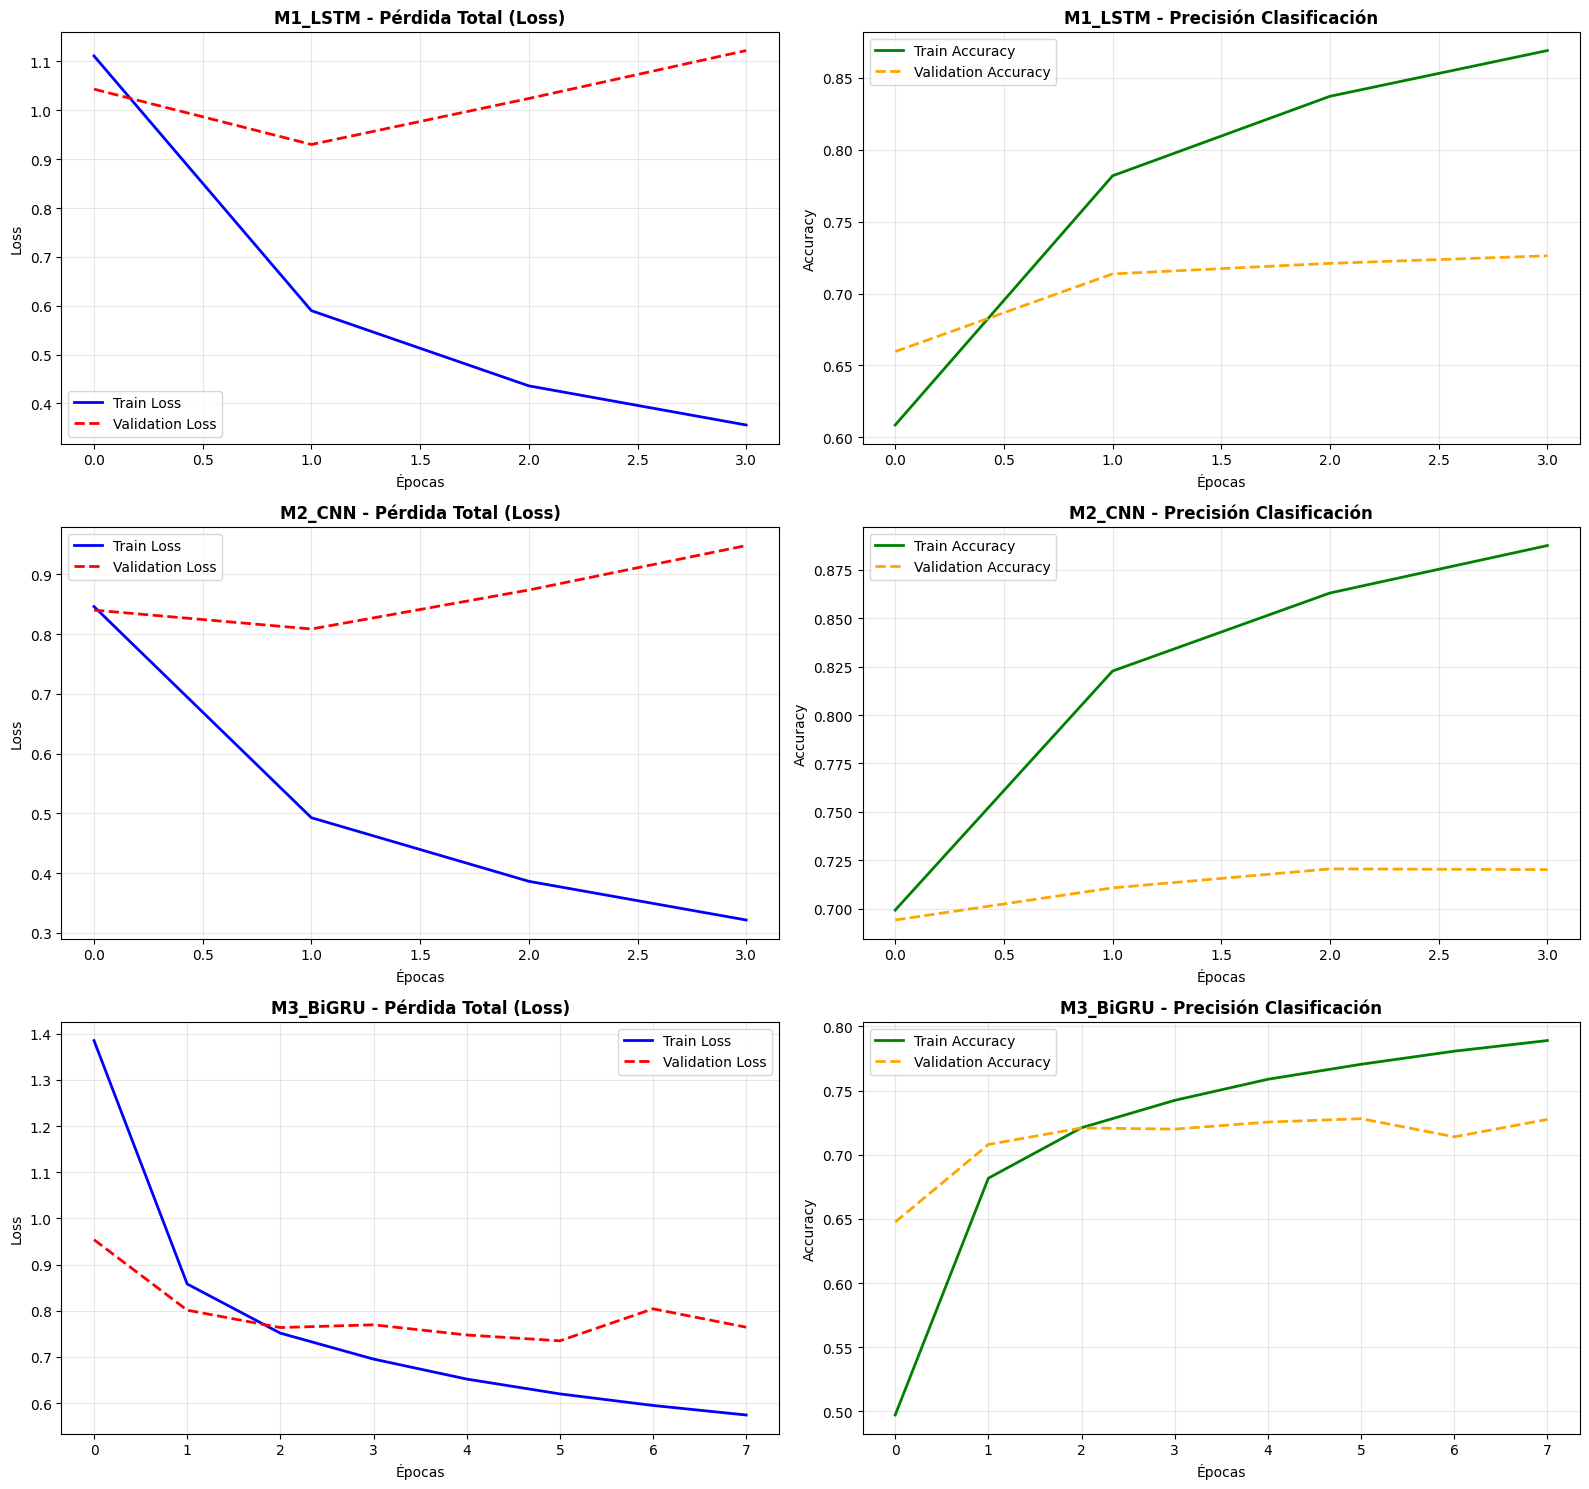


🎯 MÉTRICAS DE VALIDACIÓN EN CLASIFICACIÓN (ENSEMBLE)
              precision    recall  f1-score   support

      ALTICA     0.9887    0.8178    0.8952      2991
   BLACK_ROT     0.7678    0.6535    0.7060     32278
    BOTRYTIS     0.6022    0.5234    0.5600     32079
    EMPOASCA     0.9617    0.9880    0.9747     23275
    ERINOSIS     0.5150    0.5968    0.5529     11706
        ESCA     0.9035    0.9367    0.9198     23508
     HEALTHY     0.8407    0.9099    0.8739     36695
     LOBESIA     0.6948    0.7680    0.7295     22104
      MILDIU     0.3687    0.4449    0.4032     14688
       OIDIO     0.9514    0.9226    0.9368      5619
    RED_MITE     0.8854    0.4754    0.6186      4453

    accuracy                         0.7475    209396
   macro avg     0.7709    0.7306    0.7428    209396
weighted avg     0.7527    0.7475    0.7467    209396



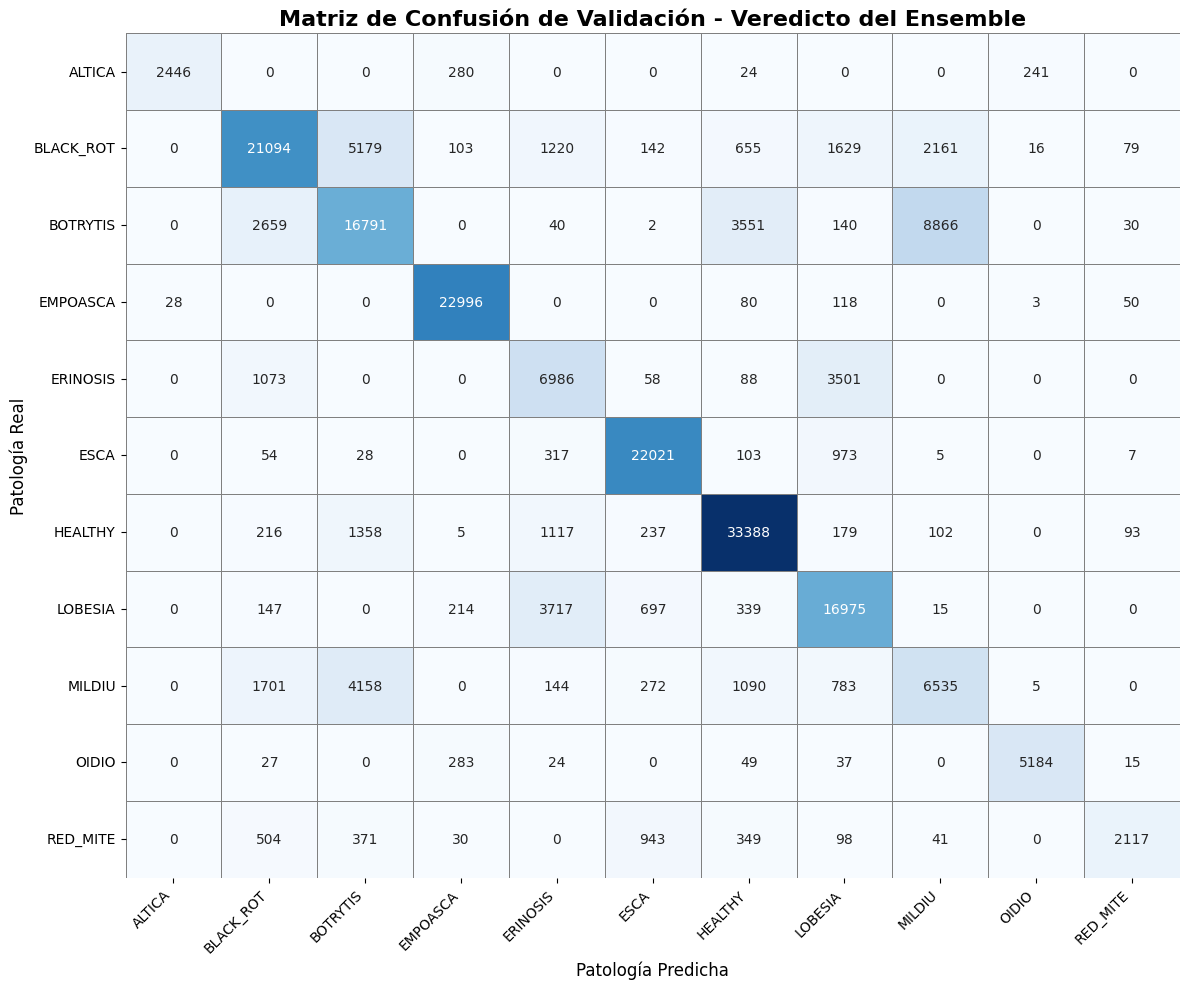


📈 MÉTRICAS DE REGRESIÓN (ENSEMBLE)
MAE  (Mean Absolute Error):      0.0637  (Error medio absoluto en la predicción del daño 0-1)
MSE  (Mean Squared Error):       0.0091  (Penaliza errores grandes)
RMSE (Root Mean Squared Error):  0.0955  (Error estándar en las mismas unidades que la salida)
R2   (Coeficiente Determinación): 0.8749  (Varianza explicada por el modelo. Max 1.0)
EVALUACIÓN DE RENDIMIENTO INDIVIDUAL POR MODELO EN VALIDACIÓN

--------------------------------------------------
🧠 Evaluando modelo: M1_LSTM
--------------------------------------------------
🎯 Métricas de Clasificación:
  - Accuracy:  0.7136 (Precisión global)
  - Precision: 0.7002 (Media Macro)
  - Recall:    0.6916 (Media Macro)
  - F1-Score:  0.6941 (Media Macro)

📈 Métricas de Regresión:
  - MAE:  0.0776
  - RMSE: 0.1151
  - R2:   0.8183

--------------------------------------------------
🧠 Evaluando modelo: M2_CNN
--------------------------------------------------
🎯 Métricas de Clasificación:
  - Accuracy: 

,Accuracy,F1-Score,MAE,R2
M1_LSTM,0.7136,0.6941,0.0776,0.8183
M2_CNN,0.7108,0.7110,0.0756,0.8281
M3_BiGRU,0.7281,0.7271,0.0740,0.8426


In [ ]:
# CARGA DE PREPROCESADORES
# ==============================================================================
scaler = joblib.load("pruebas/standardscaler/scaler.pkl")
le = joblib.load("pruebas/standardscaler/label_encoder.pkl")
print("✅ Preprocesadores (Scaler y LabelEncoder) cargados correctamente.")

# CARGA DE MODELOS
# ==============================================================================
m1_lstm = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_LSTM)
m2_cnn = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_CNN)
m3_bigru = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_BI_GRU)

modelos = [m1_lstm, m2_cnn, m3_bigru]
print("✅ Modelos cargados correctamente.")

# CARGA DE HISTORIALES
# ==============================================================================
historiales = []

for modelo in modelos:
    ruta_historial = RUTA_MODELS_DIR / f"history_{modelo.name}.pkl"
    with open(ruta_historial, 'rb') as f:
        historial = pickle.load(f)
        historiales.append(historial)
    print(f"📊 Historial de {modelo.name} cargado con éxito.")

print("\n🚀 ¡Todos los artefactos y modelos han sido cargados y están listos para usarse!")

# ==============================================================================
# LÓGICA DE INFERENCIA DEL ENSEMBLE (SOFT VOTING & AVERAGING)
# ==============================================================================
def predecir_ensemble(X_input, modelos_ensemble, label_encoder):
    """
    X_input: Tensor de entrada con shape (N, WINDOW_SIZE, 12)
    modelos_ensemble: Lista con los 3 modelos entrenados
    """
    preds_clases_prob = []
    preds_regresion = []
    
    # 1. Obtener predicciones crudas de cada modelo
    for mod in modelos_ensemble:
        p_class, p_reg = mod.predict(X_input, batch_size=512, verbose=0)
        preds_clases_prob.append(p_class) # Probabilidades de Softmax
        preds_regresion.append(p_reg)     # Valores 0-1 de Sigmoide
        
    # 2. SOFT VOTING (Clasificación): Media de las probabilidades
    media_probs = np.mean(preds_clases_prob, axis=0)
    clases_finales_idx = np.argmax(media_probs, axis=1)
    confianza_final = np.max(media_probs, axis=1)
    nombres_clases = label_encoder.inverse_transform(clases_finales_idx)
    
    # 3. SIMPLE AVERAGING (Regresión): Media del grado de infección
    grado_final = np.mean(preds_regresion, axis=0).flatten()
    
    return nombres_clases, grado_final, confianza_final

# --- PRUEBA DEL ENSEMBLE SOBRE DATOS DE VALIDACIÓN ---
print("\n🧪 Evaluando Ensemble sobre los datos de Validación...")
pred_clase, pred_grado, pred_confianza = predecir_ensemble(X_val, modelos, le)

# ==============================================================================
# EVALUACIÓN VISUAL Y MÉTRICAS DE VALIDACIÓN
# ==============================================================================

# --- 1. GRÁFICAS DE PÉRDIDA (LEARNING CURVES) ---
print("📊 Generando curvas de aprendizaje para auditar el sobreajuste (Overfitting)...")

fig, axes = plt.subplots(len(historiales), 2, figsize=(16, 5 * len(historiales)))

for i, (hist, modelo) in enumerate(zip(historiales, modelos)):
    # Gráfica de Pérdida Total (Loss)
    axes[i, 0].plot(hist['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[i, 0].plot(hist['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
    axes[i, 0].set_title(f'{modelo.name} - Pérdida Total (Loss)', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].set_xlabel('Épocas')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    # Gráfica de Precisión de Clasificación (Accuracy)
    # Keras nombra las métricas combinando el nombre de la capa de salida
    acc_key = 'out_class_accuracy' if 'out_class_accuracy' in hist else 'accuracy'
    val_acc_key = 'val_out_class_accuracy' if 'val_out_class_accuracy' in hist else 'val_accuracy'
    
    if acc_key in hist:
        axes[i, 1].plot(hist[acc_key], label='Train Accuracy', color='green', linewidth=2)
        axes[i, 1].plot(hist[val_acc_key], label='Validation Accuracy', color='orange', linestyle='--', linewidth=2)
        axes[i, 1].set_title(f'{modelo.name} - Precisión Clasificación', fontsize=12, fontweight='bold')
        axes[i, 1].set_ylabel('Accuracy')
        axes[i, 1].set_xlabel('Épocas')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 2. MÉTRICAS DE CLASIFICACIÓN (QUÉ PATOLOGÍA ES) ---
print("\n" + "="*50)
print("🎯 MÉTRICAS DE VALIDACIÓN EN CLASIFICACIÓN (ENSEMBLE)")
print("="*50)

y_val_real_nombres = le.inverse_transform(y_val_class)

# Classification Report (Incluye Precision, Recall, F1-Score y Accuracy Macro)
reporte = classification_report(y_val_real_nombres, pred_clase, digits=4)
print(reporte)

# Matriz de Confusión
cm = confusion_matrix(y_val_real_nombres, pred_clase, labels=le.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar=False, linewidths=0.5, linecolor='gray')
plt.title('Matriz de Confusión de Validación - Veredicto del Ensemble', fontsize=16, fontweight='bold')
plt.ylabel('Patología Real', fontsize=12)
plt.xlabel('Patología Predicha', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 3. MÉTRICAS DE REGRESIÓN (CUÁNTO DAÑO HAY) ---
print("\n" + "="*50)
print("📈 MÉTRICAS DE REGRESIÓN (ENSEMBLE)")
print("="*50)

mae = mean_absolute_error(y_val_reg, pred_grado)
mse = mean_squared_error(y_val_reg, pred_grado)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_reg, pred_grado)

print(f"MAE  (Mean Absolute Error):      {mae:.4f}  (Error medio absoluto en la predicción del daño 0-1)")
print(f"MSE  (Mean Squared Error):       {mse:.4f}  (Penaliza errores grandes)")
print(f"RMSE (Root Mean Squared Error):  {rmse:.4f}  (Error estándar en las mismas unidades que la salida)")
print(f"R2   (Coeficiente Determinación): {r2:.4f}  (Varianza explicada por el modelo. Max 1.0)")
print("="*50)

# ==============================================================================
# EVALUACIÓN INDIVIDUAL POR MODELO (LSTM, CNN, BiGRU)
# ==============================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*60)
print("EVALUACIÓN DE RENDIMIENTO INDIVIDUAL POR MODELO EN VALIDACIÓN")
print("="*60)

# Convertimos las etiquetas reales a sus nombres en texto para la matriz de confusión
y_val_real_nombres = le.inverse_transform(y_val_class)

# Diccionario para ir guardando un resumen y poder comparar al final
resumen_metricas = {}

for modelo in modelos:
    print(f"\n" + "-" * 50)
    print(f"🧠 Evaluando modelo: {modelo.name}")
    print("-" * 50)
    
    # 1. PREDICCIÓN
    # El modelo devuelve dos arrays: probabilidades de clasificación y valores de regresión
    p_class, p_reg = modelo.predict(X_val, batch_size=512, verbose=0)
    
    # Procesamos las salidas
    pred_clases_idx = np.argmax(p_class, axis=1)
    pred_grado = p_reg.flatten()
    pred_clases_nombres = le.inverse_transform(pred_clases_idx)
    
    # 2. MÉTRICAS DE CLASIFICACIÓN (Macro average)
    acc = accuracy_score(y_val_class, pred_clases_idx)
    prec = precision_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    rec = recall_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    f1 = f1_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    
    print(f"🎯 Métricas de Clasificación:")
    print(f"  - Accuracy:  {acc:.4f} (Precisión global)")
    print(f"  - Precision: {prec:.4f} (Media Macro)")
    print(f"  - Recall:    {rec:.4f} (Media Macro)")
    print(f"  - F1-Score:  {f1:.4f} (Media Macro)")
    
    # 3. MÉTRICAS DE REGRESIÓN
    mae = mean_absolute_error(y_val_reg, pred_grado)
    rmse = np.sqrt(mean_squared_error(y_val_reg, pred_grado))
    r2 = r2_score(y_val_reg, pred_grado)
    
    print(f"\n📈 Métricas de Regresión:")
    print(f"  - MAE:  {mae:.4f}")
    print(f"  - RMSE: {rmse:.4f}")
    print(f"  - R2:   {r2:.4f}")
    
    # Guardamos en el diccionario para imprimir una tabla resumen luego
    resumen_metricas[modelo.name] = {
        'Accuracy': acc, 'F1-Score': f1, 'MAE': mae, 'R2': r2
    }
    
# ==============================================================================
# TABLA RESUMEN FINAL
# ==============================================================================
print("\n" + "="*60)
print("📊 RESUMEN COMPARATIVO DE LOS MODELOS")
print("="*60)
df_resumen = pd.DataFrame(resumen_metricas).T
display(df_resumen.round(4))

## **MinMaxScaler**

In [2]:
from sklearn.preprocessing import MinMaxScaler

# =========================================================
# CONFIGURACIONES DEL MODELO:
# =========================================================
DIAS_CONTEXTO = 7
WINDOW_SIZE = DIAS_CONTEXTO * 24    # Horas de contexto
BATCH_SIZE = 512   # Memoria
EPOCHS = 50         # Epocas de entrenamiento
EARLY_STOPPING = 2  # Patience

# ==========================================================
# CARGA DE DATOS:
# ==========================================================
df = pd.read_parquet("../../data/processed/data_vin_processed.parquet")

# ==========================================================
# PREPROCESAMIENTO:
# ==========================================================
# Orden alfabético
df = df.reindex(sorted(df.columns), axis=1)

# Asegurar tipos string para evitar errores en el modelo:
cols_str = ['Etiqueta_Clase', 'Clase_Entrenamiento']
for col in cols_str:
    if col in df.columns:
        df[col] = df[col].astype(str)

# 1. CODIFICACIÓN DE TARGETS
le = LabelEncoder()
# TARGET: El estado real en ese instante temporal
df['Etiqueta_Num'] = le.fit_transform(df['Clase_Entrenamiento']) 
print(f"✅ Clases codificadas: {dict(zip(le.classes_, range(len(le.classes_))))}")

# 2. SELECCIÓN DE VARIABLES
# Quitamos Fecha (ya no sirve a la red), ID_Serie (no es predictiva) y Etiquetas crudas
cols_features = [
    'Temp_Amb_C', 
    'Hum_Rel_Pct', 'Lluvia_mm', 'Viento_kmh', 
    'Horas_Humedad_Foliar', 'GDD_Acumulado', 
    'Hum_Suelo_Pct', 'pH_Suelo',
    'Hora_Sin', 'Hora_Cos',
    'CO2_ppm', 'VOC_ppb'
]

target_class = 'Etiqueta_Num'
target_reg = 'Grado_Infeccion'

# 3. SPLIT ESTRATÉGICO ESTRATIFICADO (POR ID_SERIE, NUNCA ALEATORIO POR FILA)
# Obtenemos un diccionario 1 a 1 de cada ID_Serie con su patología general
df_unicos = df.drop_duplicates(subset=['ID_Serie'])[['ID_Serie', 'Etiqueta_Clase']]

ids = df_unicos['ID_Serie']
etiquetas = df_unicos['Etiqueta_Clase']

# Primer Split: 70% Train, 30% Temp (Estratificado por la etiqueta)
train_ids, temp_ids, _, temp_etiquetas = train_test_split(
    ids, etiquetas, 
    test_size=0.30, 
    random_state=42, 
    stratify=etiquetas
)

# Segundo Split: Dividimos el 30% restante en 15% Val y 15% Test
val_ids, test_ids = train_test_split(
    temp_ids, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_etiquetas
)

# Reconstruimos los DataFrames completos usando los IDs seleccionados
train_df = df[df['ID_Serie'].isin(train_ids)].copy()
val_df = df[df['ID_Serie'].isin(val_ids)].copy()
test_df = df[df['ID_Serie'].isin(test_ids)].copy()

print(f"📊 Series separadas -> Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

# 4. ESCALADO
scaler = MinMaxScaler()
# Ajustamos solo en train para evitar fuga de datos
scaler.fit(train_df[cols_features])

# Transformamos todos
train_df[cols_features] = scaler.transform(train_df[cols_features])
val_df[cols_features] = scaler.transform(val_df[cols_features])
test_df[cols_features] = scaler.transform(test_df[cols_features])
print("✅ Datos escalados correctamente.")

# 5. GENERACIÓN DE VENTANAS TEMPORALES (MEMORIA OPTIMIZADA)
def crear_secuencias(df_part, window_size, features, t_class, t_reg):
    X, y_c, y_r = [], [], []
    grupos = df_part.groupby('ID_Serie')
    
    for _, grupo in tqdm(grupos, desc="Generando tensores", leave=False):
        data_features = grupo[features].values
        data_class = grupo[t_class].values
        data_reg = grupo[t_reg].values
        
        # Deslizamiento de ventana
        for i in range(len(data_features) - window_size):
            X.append(data_features[i : i + window_size])
            # El target es el estado al FINAL de la ventana
            y_c.append(data_class[i + window_size])
            y_r.append(data_reg[i + window_size])
            
    return np.array(X, dtype=np.float32), np.array(y_c, dtype=np.int8), np.array(y_r, dtype=np.float32)

print("\n🚀 Empaquetando tensores 3D (Esto tomará un minuto)...")
X_train, y_train_class, y_train_reg = crear_secuencias(train_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_val, y_val_class, y_val_reg = crear_secuencias(val_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_test, y_test_class, y_test_reg = crear_secuencias(test_df, WINDOW_SIZE, cols_features, target_class, target_reg)

# Limpiar RAM
del train_df, val_df, test_df
gc.collect()

# ==============================================================================
# DEEP ENSEMBLE LEARNING: DEFINICIÓN DE LAS 3 REDES
# ==============================================================================
NUM_FEATURES = len(cols_features)  # 12
NUM_CLASSES = len(le.classes_)     # 11
tf.keras.utils.set_random_seed(42)

def compilar_modelo(modelo, lr):
    modelo.compile(
        optimizer=Adam(learning_rate=lr),
        loss={"out_class": "sparse_categorical_crossentropy", "out_reg": "mse"},
        loss_weights={"out_class": 1.0, "out_reg": 1.0},
        metrics={"out_class": ["accuracy"], "out_reg": ["mae"]}
    )
    return modelo

# --- MODELO 1: LSTM PURA ---
def build_lstm_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M1")
    x = LSTM(32, return_sequences=True)(inp)  
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)                       
    x = LSTM(16)(x)                           
    x = BatchNormalization()(x)
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M1_LSTM"), lr=0.001)

# --- MODELO 2: CNN-1D ---
def build_cnn_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M2")
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inp)
    x = BatchNormalization()(x)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)                                                           
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M2_CNN"), lr=0.001)

# --- MODELO 3: GRU BIDIRECCIONAL ---
def build_bigru_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M3")
    x = Bidirectional(GRU(16, return_sequences=False))(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(16, activation='relu')(x)
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M3_BiGRU"), lr=0.001)

# Instanciamos los 3 modelos
m1_lstm = build_lstm_model()
m2_cnn = build_cnn_model()
m3_bigru = build_bigru_model()

✅ Clases codificadas: {'ALTICA': 0, 'BLACK_ROT': 1, 'BOTRYTIS': 2, 'EMPOASCA': 3, 'ERINOSIS': 4, 'ESCA': 5, 'HEALTHY': 6, 'LOBESIA': 7, 'MILDIU': 8, 'OIDIO': 9, 'RED_MITE': 10}
📊 Series separadas -> Train: 692 | Val: 148 | Test: 149
✅ Datos escalados correctamente.

🚀 Empaquetando tensores 3D (Esto tomará un minuto)...


In [3]:
# ==============================================================================
# ENTRENAMIENTO DEL ENSEMBLE Y GUARDADO DE ARTEFACTOS
# ==============================================================================

RUTA_MODELS_DIR = Path("pruebas/minmax_scaler/")
NOMBRE_MODELO_LSTM = "M1_LSTM.keras"
NOMBRE_MODELO_CNN = "M2_CNN.keras"
NOMBRE_MODELO_BI_GRU = "M3_BiGRU.keras"

# 1. Guardar los preprocesadores inmediatamente de forma segura
joblib.dump(scaler, "pruebas/minmax_scaler/scaler.pkl")
joblib.dump(le, "pruebas/minmax_scaler/label_encoder.pkl")
print("Preprocesadores guardados en: pruebas/minmax_scaler/")

modelos = [m1_lstm, m2_cnn, m3_bigru]
historiales = []

print("\nIniciando entrenamiento secuencial de redes: ", len(modelos))

start_time_total = time.time()      # INICIO DE CRONÓMETRO TOTAL

for i, modelo in enumerate(modelos):
    print("\n" + "="*50)
    print("Entrenando Modelo: ", modelo.name)
    print("="*50)
    
    start_time_model = time.time()  # INICIO DE CRONÓMETRO MODELO

    # Pre-definimos la ruta donde se guardara ESTE modelo en concreto
    ruta_modelo = RUTA_MODELS_DIR / f"{modelo.name}.keras"
    
    # Instanciamos los Callbacks desde cero para que no crucen historial entre redes
    early_stop_individual = EarlyStopping(
        monitor='val_loss', 
        patience=EARLY_STOPPING, 
        restore_best_weights=True,
        verbose=1
    )
    
    checkpoint_individual = ModelCheckpoint(
        filepath=ruta_modelo,
        monitor='val_loss',        # Vigilamos la perdida de validacion global
        save_best_only=True,       # Solo sobreescribe si la red mejora en esta epoca
        mode='min',                # Queremos minimizar el val_loss
        verbose=1
    )
    
    # Inicia el entrenamiento (Fit)
    hist = modelo.fit(
        X_train, 
        {"out_class": y_train_class, "out_reg": y_train_reg},
        validation_data=(X_val, {"out_class": y_val_class, "out_reg": y_val_reg}),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop_individual, checkpoint_individual],
        verbose=1
    )
    
    # La red (.keras) ya ha sido guardada en su mejor punto por el Checkpoint.
    # Ahora solo necesitamos guardar el historial de la funcion de perdida.
    ruta_historial = RUTA_MODELS_DIR / f"history_{modelo.name}.pkl"
    with open(ruta_historial, 'wb') as f:
        pickle.dump(hist.history, f)
        
    historiales.append(hist.history)
    print("Historial guardado con exito: ", modelo.name)

    end_time_model = time.time()    # FIN DE CRONÓMETRO MODELO
    elapsed_model_mins = (end_time_model - start_time_model) / 60.0
    print(f"⏱️ Tiempo de entrenamiento para {modelo.name}: {elapsed_model_mins:.2f} minutos.")

end_time_total = time.time()        # FIN DE CRONÓMETRO TOTAL
elapsed_total_mins = (end_time_total - start_time_total) / 60.0
print(f"\n⏱️ TIEMPO TOTAL DE ENTRENAMIENTO DEL ENSEMBLE: {elapsed_total_mins:.2f} minutos.")

print("\nENTRENAMIENTO Y EXPORTACION COMPLETADOS. Todos los archivos estan seguros en: ", RUTA_MODELS_DIR.resolve())

Preprocesadores guardados en: pruebas/minmax_scaler/

Iniciando entrenamiento secuencial de redes:  3

Entrenando Modelo:  M1_LSTM
Epoch 1/50
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 1.6634 - out_class_accuracy: 0.4198 - out_class_loss: 1.6120 - out_reg_loss: 0.0514 - out_reg_mae: 0.1689
Epoch 1: val_loss improved from None to 1.42125, saving model to pruebas\minmax_scaler\M1_LSTM.keras
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 211s 104ms/step - loss: 1.3442 - out_class_accuracy: 0.5164 - out_class_loss: 1.3130 - out_reg_loss: 0.0312 - out_reg_mae: 0.1273 - val_loss: 1.4213 - val_out_class_accuracy: 0.5091 - val_out_class_loss: 1.3959 - val_out_reg_loss: 0.0255 - val_out_reg_mae: 0.1120
Epoch 2/50
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.9112 - out_class_accuracy: 0.6617 - out_class_loss: 0.8956 - out_reg_loss: 0.0156 - out_reg_mae: 0.0880
Epoch 2: val_loss improved from 1.42125 to 1.26844, saving model to pruebas\minmax_scaler\M1_LSTM.keras
2010/2010 ━━━━━━━━━━━━━━━━━━━━

✅ Preprocesadores (Scaler y LabelEncoder) cargados correctamente.
✅ Modelos cargados correctamente.
📊 Historial de M1_LSTM cargado con éxito.
📊 Historial de M2_CNN cargado con éxito.
📊 Historial de M3_BiGRU cargado con éxito.

🚀 ¡Todos los artefactos y modelos han sido cargados y están listos para usarse!

🧪 Evaluando Ensemble sobre los datos de Validación...
📊 Generando curvas de aprendizaje para auditar el sobreajuste (Overfitting)...


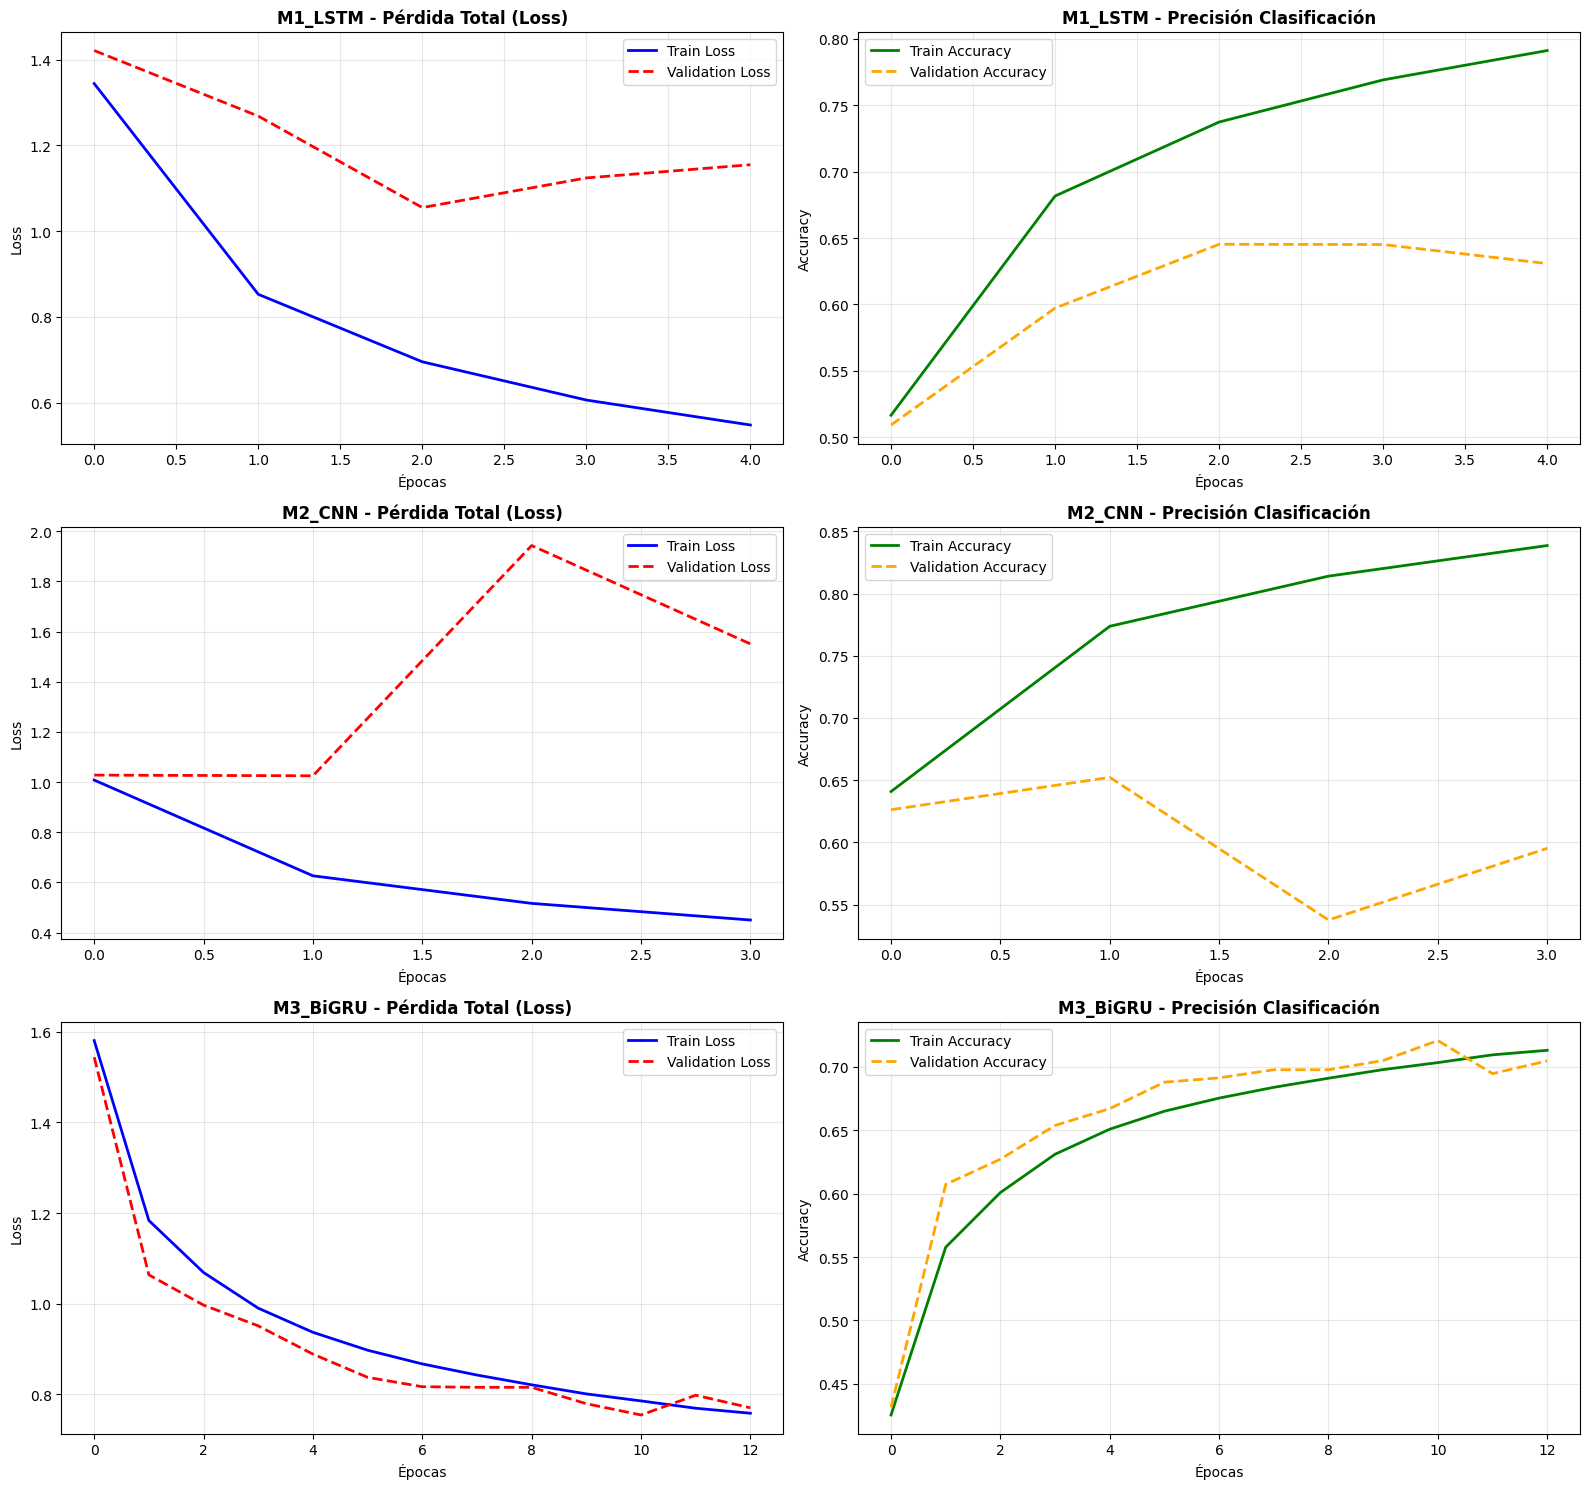


🎯 MÉTRICAS DE VALIDACIÓN EN CLASIFICACIÓN (ENSEMBLE)
              precision    recall  f1-score   support

      ALTICA     0.9230    0.8937    0.9081      2991
   BLACK_ROT     0.7452    0.6028    0.6665     32278
    BOTRYTIS     0.5945    0.5062    0.5468     32079
    EMPOASCA     0.9471    0.9672    0.9570     23275
    ERINOSIS     0.5242    0.6574    0.5833     11706
        ESCA     0.8303    0.9358    0.8799     23508
     HEALTHY     0.7940    0.9415    0.8615     36695
     LOBESIA     0.7643    0.6632    0.7102     22104
      MILDIU     0.3643    0.4454    0.4008     14688
       OIDIO     0.8870    0.9151    0.9008      5619
    RED_MITE     0.9098    0.3445    0.4998      4453

    accuracy                         0.7307    209396
   macro avg     0.7531    0.7157    0.7195    209396
weighted avg     0.7355    0.7307    0.7261    209396



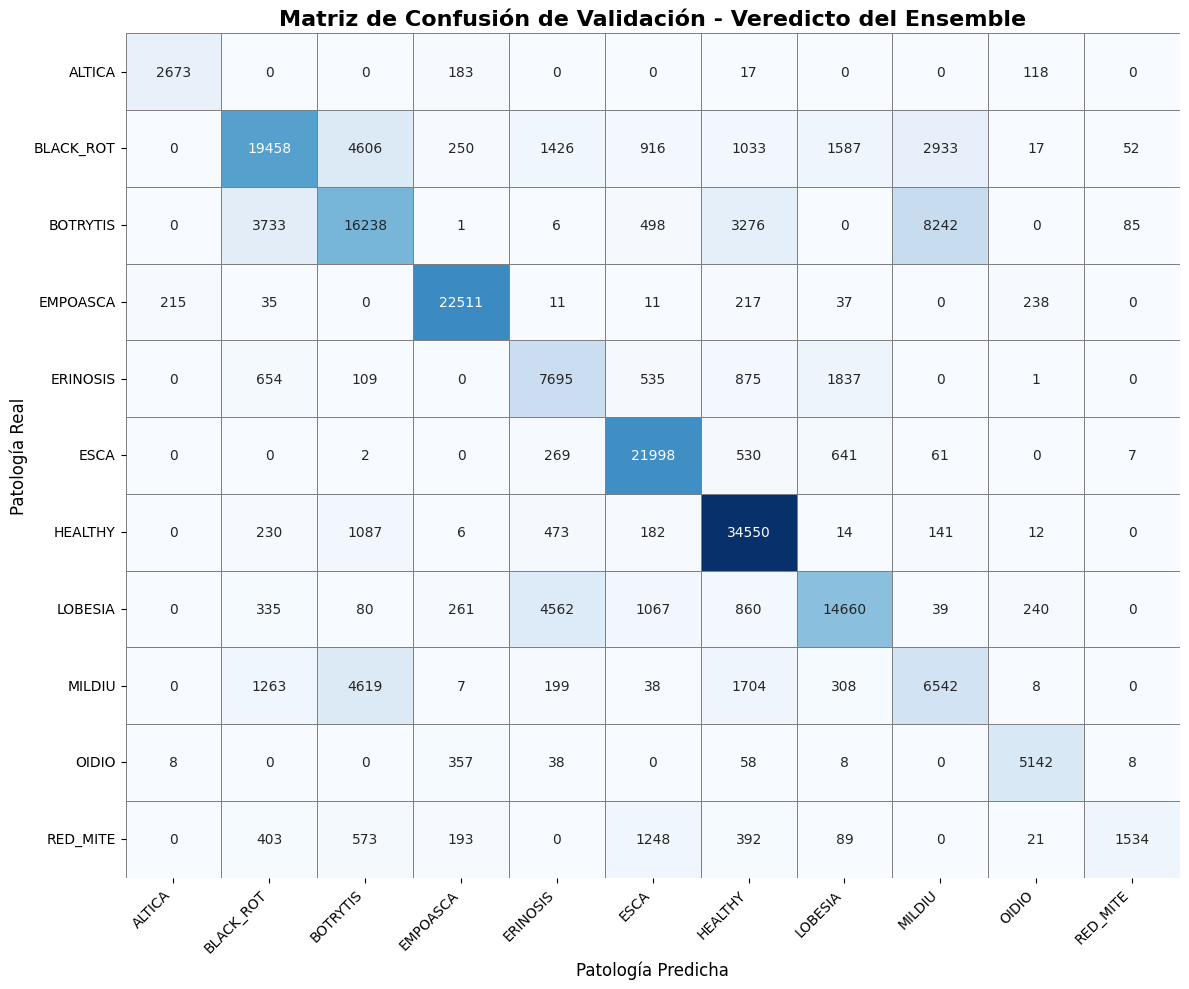


📈 MÉTRICAS DE REGRESIÓN (ENSEMBLE)
MAE  (Mean Absolute Error):      0.0646  (Error medio absoluto en la predicción del daño 0-1)
MSE  (Mean Squared Error):       0.0090  (Penaliza errores grandes)
RMSE (Root Mean Squared Error):  0.0950  (Error estándar en las mismas unidades que la salida)
R2   (Coeficiente Determinación): 0.8762  (Varianza explicada por el modelo. Max 1.0)
EVALUACIÓN DE RENDIMIENTO INDIVIDUAL POR MODELO EN VALIDACIÓN

--------------------------------------------------
🧠 Evaluando modelo: M1_LSTM
--------------------------------------------------
🎯 Métricas de Clasificación:
  - Accuracy:  0.6453 (Precisión global)
  - Precision: 0.6757 (Media Macro)
  - Recall:    0.6150 (Media Macro)
  - F1-Score:  0.6332 (Media Macro)

📈 Métricas de Regresión:
  - MAE:  0.0815
  - RMSE: 0.1178
  - R2:   0.8097

--------------------------------------------------
🧠 Evaluando modelo: M2_CNN
--------------------------------------------------
🎯 Métricas de Clasificación:
  - Accuracy: 

,Accuracy,F1-Score,MAE,R2
M1_LSTM,0.6453,0.6332,0.0815,0.8097
M2_CNN,0.6523,0.6402,0.0819,0.8138
M3_BiGRU,0.7205,0.6922,0.0727,0.8362


In [4]:
# CARGA DE PREPROCESADORES
# ================ ==============================================================
scaler = joblib.load("pruebas/minmax_scaler/scaler.pkl")
le = joblib.load("pruebas/minmax_scaler/label_encoder.pkl")
print("✅ Preprocesadores (Scaler y LabelEncoder) cargados correctamente.")

# CARGA DE MODELOS
# ==============================================================================
m1_lstm = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_LSTM)
m2_cnn = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_CNN)
m3_bigru = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_BI_GRU)

modelos = [m1_lstm, m2_cnn, m3_bigru]
print("✅ Modelos cargados correctamente.")

# CARGA DE HISTORIALES
# ==============================================================================
historiales = []

for modelo in modelos:
    ruta_historial = RUTA_MODELS_DIR / f"history_{modelo.name}.pkl"
    with open(ruta_historial, 'rb') as f:
        historial = pickle.load(f)
        historiales.append(historial)
    print(f"📊 Historial de {modelo.name} cargado con éxito.")

print("\n🚀 ¡Todos los artefactos y modelos han sido cargados y están listos para usarse!")

# ==============================================================================
# LÓGICA DE INFERENCIA DEL ENSEMBLE (SOFT VOTING & AVERAGING)
# ==============================================================================
def predecir_ensemble(X_input, modelos_ensemble, label_encoder):
    """
    X_input: Tensor de entrada con shape (N, WINDOW_SIZE, 12)
    modelos_ensemble: Lista con los 3 modelos entrenados
    """
    preds_clases_prob = []
    preds_regresion = []
    
    # 1. Obtener predicciones crudas de cada modelo
    for mod in modelos_ensemble:
        p_class, p_reg = mod.predict(X_input, batch_size=512, verbose=0)
        preds_clases_prob.append(p_class) # Probabilidades de Softmax
        preds_regresion.append(p_reg)     # Valores 0-1 de Sigmoide
        
    # 2. SOFT VOTING (Clasificación): Media de las probabilidades
    media_probs = np.mean(preds_clases_prob, axis=0)
    clases_finales_idx = np.argmax(media_probs, axis=1)
    confianza_final = np.max(media_probs, axis=1)
    nombres_clases = label_encoder.inverse_transform(clases_finales_idx)
    
    # 3. SIMPLE AVERAGING (Regresión): Media del grado de infección
    grado_final = np.mean(preds_regresion, axis=0).flatten()
    
    return nombres_clases, grado_final, confianza_final

# --- PRUEBA DEL ENSEMBLE SOBRE DATOS DE VALIDACIÓN ---
print("\n🧪 Evaluando Ensemble sobre los datos de Validación...")
pred_clase, pred_grado, pred_confianza = predecir_ensemble(X_val, modelos, le)

# ==============================================================================
# EVALUACIÓN VISUAL Y MÉTRICAS DE VALIDACIÓN
# ==============================================================================

# --- 1. GRÁFICAS DE PÉRDIDA (LEARNING CURVES) ---
print("📊 Generando curvas de aprendizaje para auditar el sobreajuste (Overfitting)...")

fig, axes = plt.subplots(len(historiales), 2, figsize=(16, 5 * len(historiales)))

for i, (hist, modelo) in enumerate(zip(historiales, modelos)):
    # Gráfica de Pérdida Total (Loss)
    axes[i, 0].plot(hist['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[i, 0].plot(hist['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
    axes[i, 0].set_title(f'{modelo.name} - Pérdida Total (Loss)', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].set_xlabel('Épocas')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    # Gráfica de Precisión de Clasificación (Accuracy)
    # Keras nombra las métricas combinando el nombre de la capa de salida
    acc_key = 'out_class_accuracy' if 'out_class_accuracy' in hist else 'accuracy'
    val_acc_key = 'val_out_class_accuracy' if 'val_out_class_accuracy' in hist else 'val_accuracy'
    
    if acc_key in hist:
        axes[i, 1].plot(hist[acc_key], label='Train Accuracy', color='green', linewidth=2)
        axes[i, 1].plot(hist[val_acc_key], label='Validation Accuracy', color='orange', linestyle='--', linewidth=2)
        axes[i, 1].set_title(f'{modelo.name} - Precisión Clasificación', fontsize=12, fontweight='bold')
        axes[i, 1].set_ylabel('Accuracy')
        axes[i, 1].set_xlabel('Épocas')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 2. MÉTRICAS DE CLASIFICACIÓN (QUÉ PATOLOGÍA ES) ---
print("\n" + "="*50)
print("🎯 MÉTRICAS DE VALIDACIÓN EN CLASIFICACIÓN (ENSEMBLE)")
print("="*50)

y_val_real_nombres = le.inverse_transform(y_val_class)

# Classification Report (Incluye Precision, Recall, F1-Score y Accuracy Macro)
reporte = classification_report(y_val_real_nombres, pred_clase, digits=4)
print(reporte)

# Matriz de Confusión
cm = confusion_matrix(y_val_real_nombres, pred_clase, labels=le.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar=False, linewidths=0.5, linecolor='gray')
plt.title('Matriz de Confusión de Validación - Veredicto del Ensemble', fontsize=16, fontweight='bold')
plt.ylabel('Patología Real', fontsize=12)
plt.xlabel('Patología Predicha', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 3. MÉTRICAS DE REGRESIÓN (CUÁNTO DAÑO HAY) ---
print("\n" + "="*50)
print("📈 MÉTRICAS DE REGRESIÓN (ENSEMBLE)")
print("="*50)

mae = mean_absolute_error(y_val_reg, pred_grado)
mse = mean_squared_error(y_val_reg, pred_grado)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_reg, pred_grado)

print(f"MAE  (Mean Absolute Error):      {mae:.4f}  (Error medio absoluto en la predicción del daño 0-1)")
print(f"MSE  (Mean Squared Error):       {mse:.4f}  (Penaliza errores grandes)")
print(f"RMSE (Root Mean Squared Error):  {rmse:.4f}  (Error estándar en las mismas unidades que la salida)")
print(f"R2   (Coeficiente Determinación): {r2:.4f}  (Varianza explicada por el modelo. Max 1.0)")
print("="*50)

# ==============================================================================
# EVALUACIÓN INDIVIDUAL POR MODELO (LSTM, CNN, BiGRU)
# ==============================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*60)
print("EVALUACIÓN DE RENDIMIENTO INDIVIDUAL POR MODELO EN VALIDACIÓN")
print("="*60)

# Convertimos las etiquetas reales a sus nombres en texto para la matriz de confusión
y_val_real_nombres = le.inverse_transform(y_val_class)

# Diccionario para ir guardando un resumen y poder comparar al final
resumen_metricas = {}

for modelo in modelos:
    print(f"\n" + "-" * 50)
    print(f"🧠 Evaluando modelo: {modelo.name}")
    print("-" * 50)
    
    # 1. PREDICCIÓN
    # El modelo devuelve dos arrays: probabilidades de clasificación y valores de regresión
    p_class, p_reg = modelo.predict(X_val, batch_size=512, verbose=0)
    
    # Procesamos las salidas
    pred_clases_idx = np.argmax(p_class, axis=1)
    pred_grado = p_reg.flatten()
    pred_clases_nombres = le.inverse_transform(pred_clases_idx)
    
    # 2. MÉTRICAS DE CLASIFICACIÓN (Macro average)
    acc = accuracy_score(y_val_class, pred_clases_idx)
    prec = precision_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    rec = recall_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    f1 = f1_score(y_val_class, pred_clases_idx, average='macro', zero_division=0)
    
    print(f"🎯 Métricas de Clasificación:")
    print(f"  - Accuracy:  {acc:.4f} (Precisión global)")
    print(f"  - Precision: {prec:.4f} (Media Macro)")
    print(f"  - Recall:    {rec:.4f} (Media Macro)")
    print(f"  - F1-Score:  {f1:.4f} (Media Macro)")
    
    # 3. MÉTRICAS DE REGRESIÓN
    mae = mean_absolute_error(y_val_reg, pred_grado)
    rmse = np.sqrt(mean_squared_error(y_val_reg, pred_grado))
    r2 = r2_score(y_val_reg, pred_grado)
    
    print(f"\n📈 Métricas de Regresión:")
    print(f"  - MAE:  {mae:.4f}")
    print(f"  - RMSE: {rmse:.4f}")
    print(f"  - R2:   {r2:.4f}")
    
    # Guardamos en el diccionario para imprimir una tabla resumen luego
    resumen_metricas[modelo.name] = {
        'Accuracy': acc, 'F1-Score': f1, 'MAE': mae, 'R2': r2
    }
    
# ==============================================================================
# TABLA RESUMEN FINAL
# ==============================================================================
print("\n" + "="*60)
print("📊 RESUMEN COMPARATIVO DE LOS MODELOS")
print("="*60)
df_resumen = pd.DataFrame(resumen_metricas).T
display(df_resumen.round(4))

## **Conclusión:**

Ante la superioridad métrica del StandardScaler en el conjunto de validación, lo seleccionamos como escalador para el modelo final.

| Scaler | Accuracy | Precisión (Macro) | Recall (Macro) | F1-Score (Macro) | R2 |
| :--- | :--- | :--- | :--- | :--- | :--- |
|StandardScaler| 0,7475 | 0,7709 | 0,7306 | 0,7428 | 0,8749 |
|MinMaxScaler  | 0,7307 | 0,7531 | 0,7157 | 0,7195 | 0,8762 |

---

# **SELECCIÓN DEL PADDING**

## **Código de carga y preparación de datos**

In [ ]:
PROCESSED_DIR = Path("../../data/processed/")
NOMBRE_INPUT_PROCESSED = "data_vin_processed.parquet"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# RUTAS DE GUARDADO DE ARTEFACTOS
RUTA_MODELS_DIR = Path("pruebas/window1sem/")
RUTA_MODELS_DIR.mkdir(parents=True, exist_ok=True)

NOMBRE_SCALER = "scaler.pkl"
NOMBRE_LABEL_ENCODER = "label_encoder.pkl"

NOMBRE_MODELO_LSTM = "M1_LSTM.keras"
NOMBRE_MODELO_CNN = "M2_CNN.keras"
NOMBRE_MODELO_BI_GRU = "M3_BiGRU.keras"

# RUTAS DE LA SALIDA DEL MODELO:
OUTPUT_DIR = Path("pruebas/padding/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NOMBRE_PREDICT_CSV = "inferencia_vid.csv"

# CONFIGURACIONES DEL MODELO:
DIAS_CONTEXTO = 7
WINDOW_SIZE = DIAS_CONTEXTO * 24    # Horas de contexto
BATCH_SIZE = 512   # Memoria
EPOCHS = 50         # Epocas de entrenamiento
EARLY_STOPPING = 2  # Patience

ruta_processed = PROCESSED_DIR / NOMBRE_INPUT_PROCESSED
df = pd.read_parquet(ruta_processed)

# ==============================================================================
# 0. ASEGURAR FORMATO
# ==============================================================================
# Orden alfabético
df = df.reindex(sorted(df.columns), axis=1)
    
# Asegurar tipos string para evitar errores en el modelo:
cols_str = ['Etiqueta_Clase', 'Clase_Entrenamiento']
for col in cols_str:
    if col in df.columns:
        df[col] = df[col].astype(str)

# ==============================================================================
# 1. CODIFICACIÓN DE TARGETS
# ==============================================================================
le = LabelEncoder()
# TARGET: El estado real en ese instante temporal
df['Etiqueta_Num'] = le.fit_transform(df['Clase_Entrenamiento']) 
print(f"✅ Clases codificadas: {dict(zip(le.classes_, range(len(le.classes_))))}")

# ==============================================================================
# 2. SELECCIÓN DE VARIABLES
# ==============================================================================
# Quitamos Fecha (ya no sirve a la red), ID_Serie (no es predictiva) y Etiquetas crudas
cols_features = [
    'Temp_Amb_C', 
    'Hum_Rel_Pct', 'Lluvia_mm', 'Viento_kmh', 
    'Horas_Humedad_Foliar', 'GDD_Acumulado', 
    'Hum_Suelo_Pct', 'pH_Suelo',
    'Hora_Sin', 'Hora_Cos',
    'CO2_ppm', 'VOC_ppb'
]

target_class = 'Etiqueta_Num'
target_reg = 'Grado_Infeccion'

# ==============================================================================
# 3. SPLIT ESTRATÉGICO ESTRATIFICADO (POR ID_SERIE, NUNCA ALEATORIO POR FILA)
# ==============================================================================
# 1. Obtenemos un diccionario 1 a 1 de cada ID_Serie con su patología general
df_unicos = df.drop_duplicates(subset=['ID_Serie'])[['ID_Serie', 'Etiqueta_Clase']]

ids = df_unicos['ID_Serie']
etiquetas = df_unicos['Etiqueta_Clase']

# 2. Primer Split: 70% Train, 30% Temp (Estratificado por la etiqueta)
train_ids, temp_ids, _, temp_etiquetas = train_test_split(
    ids, etiquetas, 
    test_size=0.30, 
    random_state=42, 
    stratify=etiquetas
)

# 3. Segundo Split: Dividimos el 30% restante en 15% Val y 15% Test
val_ids, test_ids = train_test_split(
    temp_ids, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_etiquetas
)

# 4. Reconstruimos los DataFrames completos usando los IDs seleccionados
train_df = df[df['ID_Serie'].isin(train_ids)].copy()
val_df = df[df['ID_Serie'].isin(val_ids)].copy()
test_df = df[df['ID_Serie'].isin(test_ids)].copy()

print(f"📊 Series separadas -> Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

# ==============================================================================
# 4. ESCALADO (SOLO FIT EN TRAIN)
# ==============================================================================
scaler = StandardScaler()
# Ajustamos solo en train para evitar fuga de datos
scaler.fit(train_df[cols_features])

# Transformamos todos
train_df[cols_features] = scaler.transform(train_df[cols_features])
val_df[cols_features] = scaler.transform(val_df[cols_features])
test_df[cols_features] = scaler.transform(test_df[cols_features])
print("✅ Datos escalados correctamente.")

# ==============================================================================
# 5. GENERACIÓN DE VENTANAS TEMPORALES (MEMORIA OPTIMIZADA)
# ==============================================================================
def crear_secuencias(df_part, window_size, features, t_class, t_reg):
    X, y_c, y_r = [], [], []
    
    grupos = df_part.groupby('ID_Serie')
    
    for _, grupo in tqdm(grupos, desc="Generando tensores", leave=False):
        data_features = grupo[features].values
        data_class = grupo[t_class].values
        data_reg = grupo[t_reg].values
        
        # Deslizamiento de ventana
        for i in range(len(data_features) - window_size):
            X.append(data_features[i : i + window_size])
            # El target es el estado al FINAL de la ventana
            y_c.append(data_class[i + window_size])
            y_r.append(data_reg[i + window_size])
            
    return np.array(X, dtype=np.float32), np.array(y_c, dtype=np.int8), np.array(y_r, dtype=np.float32)

print("\n🚀 Empaquetando tensores 3D (Esto tomará un minuto)...")
X_train, y_train_class, y_train_reg = crear_secuencias(train_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_val, y_val_class, y_val_reg = crear_secuencias(val_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_test, y_test_class, y_test_reg = crear_secuencias(test_df, WINDOW_SIZE, cols_features, target_class, target_reg)

# Limpiar RAM
del train_df, val_df, test_df
gc.collect()

# ==============================================================================
# 7. DEEP ENSEMBLE LEARNING: DEFINICIÓN DE LAS 3 REDES
# ==============================================================================
NUM_FEATURES = len(cols_features)  # 12
NUM_CLASSES = len(le.classes_)     # 11
tf.keras.utils.set_random_seed(42)

def compilar_modelo(modelo, lr):
    modelo.compile(
        optimizer=Adam(learning_rate=lr),
        loss={"out_class": "sparse_categorical_crossentropy", "out_reg": "mse"},
        loss_weights={"out_class": 1.0, "out_reg": 1.0},
        metrics={"out_class": ["accuracy"], "out_reg": ["mae"]}
    )
    return modelo

# --- MODELO 1: LSTM PURA ---
def build_lstm_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M1")
    x = LSTM(32, return_sequences=True)(inp)  
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)                       
    x = LSTM(16)(x)                           
    x = BatchNormalization()(x)
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M1_LSTM"), lr=0.001)

# --- MODELO 2: CNN-1D ---
def build_cnn_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M2")
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inp)
    x = BatchNormalization()(x)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)                                                           
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M2_CNN"), lr=0.001)

# --- MODELO 3: GRU BIDIRECCIONAL ---
def build_bigru_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M3")
    x = Bidirectional(GRU(16, return_sequences=False))(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(16, activation='relu')(x)
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M3_BiGRU"), lr=0.001)

# Instanciamos los 3 modelos
m1_lstm = build_lstm_model()
m2_cnn = build_cnn_model()
m3_bigru = build_bigru_model()

# CARGA DE PREPROCESADORES
# ==============================================================================
scaler = joblib.load(RUTA_MODELS_DIR / NOMBRE_SCALER)
le = joblib.load(RUTA_MODELS_DIR / NOMBRE_LABEL_ENCODER)
print("✅ Preprocesadores (Scaler y LabelEncoder) cargados correctamente.")

# CARGA DE MODELOS
# ==============================================================================
m1_lstm = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_LSTM)
m2_cnn = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_CNN)
m3_bigru = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_BI_GRU)

modelos = [m1_lstm, m2_cnn, m3_bigru]
print("✅ Modelos cargados correctamente.")

print("\n🚀 ¡Todos los artefactos y modelos han sido cargados y están listos para usarse!")

# ==============================================================================
# 9. LÓGICA DE INFERENCIA DEL ENSEMBLE (SOFT VOTING & AVERAGING)
# ==============================================================================
def predecir_ensemble(X_input, modelos_ensemble, label_encoder):
    """
    X_input: Tensor de entrada con shape (N, WINDOW_SIZE, 12)
    modelos_ensemble: Lista con los 3 modelos entrenados
    """
    preds_clases_prob = []
    preds_regresion = []
    
    # 1. Obtener predicciones crudas de cada modelo
    for mod in modelos_ensemble:
        p_class, p_reg = mod.predict(X_input, batch_size=4096, verbose=0)
        preds_clases_prob.append(p_class) # Probabilidades de Softmax
        preds_regresion.append(p_reg)     # Valores 0-1 de Sigmoide
        
    # 2. SOFT VOTING (Clasificación): Media de las probabilidades
    media_probs = np.mean(preds_clases_prob, axis=0)
    clases_finales_idx = np.argmax(media_probs, axis=1)
    confianza_final = np.max(media_probs, axis=1)
    nombres_clases = label_encoder.inverse_transform(clases_finales_idx)
    
    # 3. SIMPLE AVERAGING (Regresión): Media del grado de infección
    grado_final = np.mean(preds_regresion, axis=0).flatten()
    
    return nombres_clases, grado_final, confianza_final

# --- PRUEBA DEL ENSEMBLE SOBRE DATOS DE TEST ---
print("\n🧪 Evaluando Ensemble sobre los datos de Validación...")
pred_clase, pred_grado, pred_confianza = predecir_ensemble(X_val, modelos, le)

# Mostramos los primeros 5 resultados
resultados_val = pd.DataFrame({
    'Patología_Predicha': pred_clase,
    'Grado_Infeccion_Pred': pred_grado,
    'Confianza_IA': pred_confianza,
    'Patología_Real': le.inverse_transform(y_val_class),
    'Grado_Infeccion_Real': y_val_reg
})

## **Pruebas para elegir un tipo de Padding**

Dado que la topología del modelo *Deep Ensemble Learning* (DEL) exige un tensor de entrada con una ventana temporal estricta de 10 días, resulta imperativo definir el comportamiento del sistema ante situaciones de telemetría incompleta (por ejemplo, arranques en frío donde el sensor perimetral solo dispone de 8 días de lectura). Para determinar la estrategia más robusta y evitar la inyección de artefactos sintéticos que alteren la predicción, se ha realizado un análisis de sensibilidad sobre tres técnicas de *padding* (relleno temporal):

* **Edge Padding (Repetición Constante):** Consiste en clonar el primer registro válido de la serie hacia atrás en el tiempo temporal. Mantiene la continuidad física de la serie climática, evitando saltos algorítmicos bruscos, aunque asume el riesgo de arrastrar longitudinalmente picos anómalos si el sensor se activó durante un microevento meteorológico.

* **Zero Padding (Límite Físico Extremo):** Inyecta un valor constante escalado de -3.0 (equivalente a tres desviaciones típicas por debajo de la media poblacional). Físicamente, simula una lectura de estrés extremo (ej. caída gélida o sequedad absoluta). Se evalúa para testear la capacidad de la red neuronal para ignorar ruido severo o fallos de conexión.

* **Mean Padding (Media Histórica):** Sustituye las horas faltantes con un tensor de valor 0.0, lo cual, al revertir el `StandardScaler`, equivale exactamente a la media climática del conjunto de entrenamiento. Es la aproximación estadísticamente más neutra, presuponiendo que el agroecosistema se mantenía en sus rangos promedio durante la pérdida de señal.

### **Falta de 1 día**

In [7]:
# ==============================================================================
# ANÁLISIS DE SENSIBILIDAD: ESTRATEGIAS DE PADDING EN INFERENCIA (CORREGIDO)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, mean_squared_error

print("🧪 Evaluando impacto de las estrategias de Padding en secuencias incompletas...")

# 1. Parámetros del experimento
HORAS_REALES = 216  
HORAS_FALTANTES = WINDOW_SIZE - HORAS_REALES

# 2. Creamos copias directas del tensor
X_val_edge = X_val.copy()
X_val_zero = X_val.copy()
X_val_mean = X_val.copy()

# 3. Aplicamos Padding mediante VECTORIZACIÓN (Broadcasting matricial directo sin bucles)

# A) EDGE PADDING: Extraemos la "hora 192" de todas las muestras a la vez (shape: N, 1, 12) y la expandimos
primeros_valores = X_val[:, HORAS_FALTANTES:HORAS_FALTANTES+1, :]
X_val_edge[:, 0:HORAS_FALTANTES, :] = primeros_valores

# B) ZERO PADDING FÍSICO (Valor atípico/mínimo): 
# Inyectamos -3.0 (equivalente a 3 desviaciones típicas por debajo de la media).
X_val_zero[:, 0:HORAS_FALTANTES, :] = -3.0

# C) MEAN PADDING (Media Histórica): 
# Al usar StandardScaler previamente, la media exacta del conjunto de Train es matemáticamente 0.0
X_val_mean[:, 0:HORAS_FALTANTES, :] = 0.0

# 4. Función auxiliar para evaluar rápidamente el ensemble
def evaluar_estrategia_padding(nombre, X_modificado):
    preds_clases_prob = []
    preds_regresion = []
    
    # Inferencia
    for mod in modelos:
        p_class, p_reg = mod.predict(X_modificado, batch_size=512, verbose=0)
        preds_clases_prob.append(p_class)
        preds_regresion.append(p_reg)
        
    media_probs = np.mean(preds_clases_prob, axis=0)
    clases_finales_idx = np.argmax(media_probs, axis=1)
    grado_final = np.mean(preds_regresion, axis=0).flatten()
    
    # Métricas
    y_val_real_nombres = le.inverse_transform(y_val_class)
    nombres_predichos = le.inverse_transform(clases_finales_idx)
    
    f1 = f1_score(y_val_real_nombres, nombres_predichos, average='macro', zero_division=0)
    rmse = np.sqrt(mean_squared_error(y_val_reg, grado_final))
    
    return f1, rmse

# 5. Ejecutar evaluación comparativa
resultados_padding = {}

print("Evaluando Baseline (Serie completa original de 10 días, eliminaremos 24 horas)...")
f1_base, rmse_base = evaluar_estrategia_padding("Baseline (10 días Real)", X_val)
resultados_padding["Baseline (10 días Real)"] = {"F1-Score": f1_base, "RMSE": rmse_base}

estrategias = {
    "Edge Padding (Padding por Repetición)": X_val_edge,
    "Zero Padding Físico (-3 std)": X_val_zero,
    "Mean Padding (Media = 0.0)": X_val_mean
}

for nombre, tensor_mod in estrategias.items():
    print(f"Evaluando {nombre}...")
    f1, rmse = evaluar_estrategia_padding(nombre, tensor_mod)
    resultados_padding[nombre] = {"F1-Score": f1, "RMSE": rmse}

# 6. Mostrar tabla de resultados
print("\n" + "="*70)
print("📊 IMPACTO DE LA ESTRATEGIA DE PADDING EN INFERENCIA (Eliminamos 24 de 240 horas en total)")
print("="*70)
df_padding = pd.DataFrame(resultados_padding).T
display(df_padding.round(4))

🧪 Evaluando impacto de las estrategias de Padding en secuencias incompletas...
Evaluando Baseline (Serie completa original de 10 días, eliminaremos 24 horas)...
Evaluando Edge Padding (Padding por Repetición)...
Evaluando Zero Padding Físico (-3 std)...
Evaluando Mean Padding (Media = 0.0)...

📊 IMPACTO DE LA ESTRATEGIA DE PADDING EN INFERENCIA (Eliminamos 24 de 240 horas en total)


,F1-Score,RMSE
Baseline (10 días Real),0.7428,0.0955
Edge Padding (Padding por Repetición),0.3803,0.1974
Zero Padding Físico (-3 std),0.0713,0.2926
Mean Padding (Media = 0.0),0.1763,0.3254


### **Falta de 2 días**

In [8]:
# ==============================================================================
# ANÁLISIS DE SENSIBILIDAD: ESTRATEGIAS DE PADDING EN INFERENCIA (CORREGIDO)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, mean_squared_error

print("🧪 Evaluando impacto de las estrategias de Padding en secuencias incompletas...")

# 1. Parámetros del experimento
HORAS_REALES = 192  
HORAS_FALTANTES = WINDOW_SIZE - HORAS_REALES

# 2. Creamos copias directas del tensor
X_val_edge = X_val.copy()
X_val_zero = X_val.copy()
X_val_mean = X_val.copy()

# 3. Aplicamos Padding mediante VECTORIZACIÓN (Broadcasting matricial directo sin bucles)

# A) EDGE PADDING: Extraemos la "hora 192" de todas las muestras a la vez (shape: N, 1, 12) y la expandimos
primeros_valores = X_val[:, HORAS_FALTANTES:HORAS_FALTANTES+1, :]
X_val_edge[:, 0:HORAS_FALTANTES, :] = primeros_valores

# B) ZERO PADDING FÍSICO (Valor atípico/mínimo): 
# Inyectamos -3.0 (equivalente a 3 desviaciones típicas por debajo de la media).
X_val_zero[:, 0:HORAS_FALTANTES, :] = -3.0

# C) MEAN PADDING (Media Histórica): 
# Al usar StandardScaler previamente, la media exacta del conjunto de Train es matemáticamente 0.0
X_val_mean[:, 0:HORAS_FALTANTES, :] = 0.0

# 4. Función auxiliar para evaluar rápidamente el ensemble
def evaluar_estrategia_padding(nombre, X_modificado):
    preds_clases_prob = []
    preds_regresion = []
    
    # Inferencia
    for mod in modelos:
        p_class, p_reg = mod.predict(X_modificado, batch_size=512, verbose=0)
        preds_clases_prob.append(p_class)
        preds_regresion.append(p_reg)
        
    media_probs = np.mean(preds_clases_prob, axis=0)
    clases_finales_idx = np.argmax(media_probs, axis=1)
    grado_final = np.mean(preds_regresion, axis=0).flatten()
    
    # Métricas
    y_val_real_nombres = le.inverse_transform(y_val_class)
    nombres_predichos = le.inverse_transform(clases_finales_idx)
    
    f1 = f1_score(y_val_real_nombres, nombres_predichos, average='macro', zero_division=0)
    rmse = np.sqrt(mean_squared_error(y_val_reg, grado_final))
    
    return f1, rmse

# 5. Ejecutar evaluación comparativa
resultados_padding = {}

print("Evaluando Baseline (Serie completa original de 10 días, eliminaremos 48 horas)...")
f1_base, rmse_base = evaluar_estrategia_padding("Baseline (10 días Real)", X_val)
resultados_padding["Baseline (10 días Real)"] = {"F1-Score": f1_base, "RMSE": rmse_base}

estrategias = {
    "Edge Padding (Padding por Repetición)": X_val_edge,
    "Zero Padding Físico (-3 std)": X_val_zero,
    "Mean Padding (Media = 0.0)": X_val_mean
}

for nombre, tensor_mod in estrategias.items():
    print(f"Evaluando {nombre}...")
    f1, rmse = evaluar_estrategia_padding(nombre, tensor_mod)
    resultados_padding[nombre] = {"F1-Score": f1, "RMSE": rmse}

# 6. Mostrar tabla de resultados
print("\n" + "="*70)
print("📊 IMPACTO DE LA ESTRATEGIA DE PADDING EN INFERENCIA (Eliminamos 48 de 240 horas en total)")
print("="*70)
df_padding = pd.DataFrame(resultados_padding).T
display(df_padding.round(4))

🧪 Evaluando impacto de las estrategias de Padding en secuencias incompletas...
Evaluando Baseline (Serie completa original de 10 días, eliminaremos 48 horas)...
Evaluando Edge Padding (Padding por Repetición)...
Evaluando Zero Padding Físico (-3 std)...
Evaluando Mean Padding (Media = 0.0)...

📊 IMPACTO DE LA ESTRATEGIA DE PADDING EN INFERENCIA (Eliminamos 48 de 240 horas en total)


,F1-Score,RMSE
Baseline (10 días Real),0.7428,0.0955
Edge Padding (Padding por Repetición),0.3002,0.2330
Zero Padding Físico (-3 std),0.0317,0.3481
Mean Padding (Media = 0.0),0.0634,0.3513


## **Conclusión:**

Se concluye que el Padding por repetición es el más adecuado para este caso de uso ya que presenta una superioridad métrica en el conjunto de validación respecto al resto.

| Días Faltantes | Tipo de Padding | F1-Score (Macro) | RMSE |
| :--- | :--- | :--- | :--- |
| **0 días** | Sin Padding          | 0,7428 | 0,0955 |
| **1 DÍA**  | Por Repetición       | 0,3803 | 0,1974 |
| **1 DÍA**  | Zero Padding         | 0,0713 | 0,2926 |
| **1 DÍA**  |Padding por la Media  | 0,1763 | 0,3254 |
| **2 DÍAS** | Por Repetición       | 0,3002 | 0,2330 |
| **2 DÍAS** | Zero Padding         | 0,0317 | 0,3481 |
| **2 DÍAS** | Padding por la Media | 0,0634 | 0,3513 |

---